# DATA LOADING

In [52]:
import warnings
# To ignore all warnings
warnings.filterwarnings("ignore")

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import struct
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from collections import Counter
from skimage.feature import hog
from sklearn.metrics import  precision_score, recall_score, f1_score

In [54]:
# Link raw GitHub
train_images_url = 'https://raw.githubusercontent.com/LeeTunMT/Team_Lab1_PR/group1/DataSet_Fashion-MNIST/train-images-idx3-ubyte'
train_labels_url = 'https://raw.githubusercontent.com/LeeTunMT/Team_Lab1_PR/group1/DataSet_Fashion-MNIST/train-labels-idx1-ubyte'
test_images_url = 'https://raw.githubusercontent.com/LeeTunMT/Team_Lab1_PR/group1/DataSet_Fashion-MNIST/t10k-images-idx3-ubyte'
test_labels_url = 'https://raw.githubusercontent.com/LeeTunMT/Team_Lab1_PR/group1/DataSet_Fashion-MNIST/t10k-labels-idx1-ubyte'

import requests
import struct
import numpy as np

# Function to download files from a URL
def download_file(url, filename):
    response = requests.get(url)
    with open(filename, 'wb') as f:
        f.write(response.content)

# Function to load the image files
def load_images(file_path):
    with open(file_path, 'rb') as f:
        magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.fromfile(f, dtype=np.uint8).reshape(num_images, rows * cols)
    return images

# Function to load the label files
def load_labels(file_path):
    with open(file_path, 'rb') as f:
        magic, num_labels = struct.unpack(">II", f.read(8))
        labels = np.fromfile(f, dtype=np.uint8)
    return labels

# Tải dữ liệu từ GitHub
download_file(train_images_url, 'train-images-idx3-ubyte')
download_file(train_labels_url, 'train-labels-idx1-ubyte')
download_file(test_images_url, 't10k-images-idx3-ubyte')
download_file(test_labels_url, 't10k-labels-idx1-ubyte')

# Loading training data
train_images = load_images('train-images-idx3-ubyte')
train_labels = load_labels('train-labels-idx1-ubyte')

# Loading testing data
test_images = load_images('t10k-images-idx3-ubyte')
test_labels = load_labels('t10k-labels-idx1-ubyte')

print("Training images shape:", train_images.shape)
print("Training labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)


Training images shape: (60000, 784)
Training labels shape: (60000,)
Test images shape: (10000, 784)
Test labels shape: (10000,)


##  Exploratory Data Analysis (EDA)

### Show label

In [55]:
def showOneImage(row, df=train_images, colors="gray"):
    plt.imshow(df[row].reshape(28, 28), cmap=colors)
    plt.xticks([])
    plt.yticks([])
    plt.show()

# Function to display multiple images of a given label
def showLabel(label, df=train_images, labels=train_labels, n=50):
    labelselect = df[labels == label]
    plt.figure(figsize=(10, 5), dpi=150)
    for i in range(min(n, len(labelselect))):
        plt.subplot(n // 10, 10, i + 1)
        image_data = labelselect[i].reshape(28, 28)
        plt.imshow(image_data, cmap='gray')
        plt.xticks([])
        plt.yticks([])
    plt.show()

'label 0'

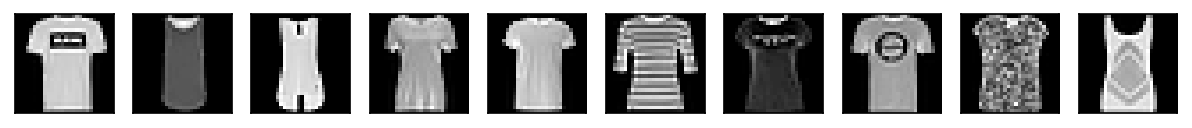

'label 1'

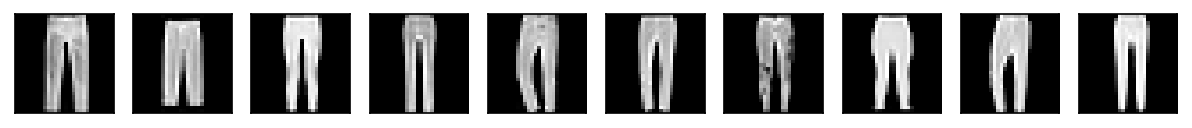

'label 2'

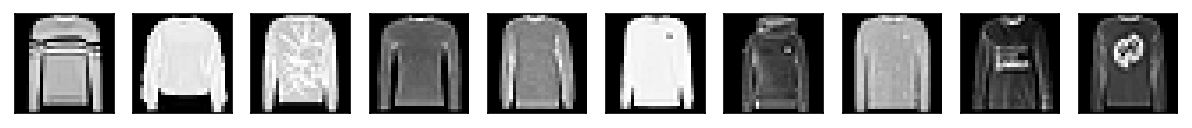

'label 3'

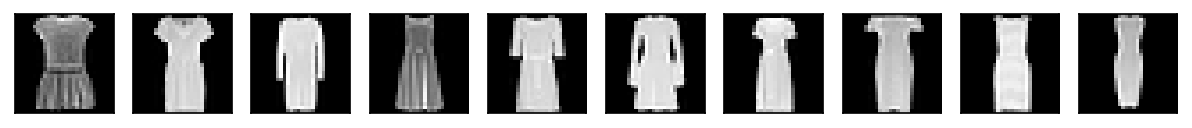

'label 4'

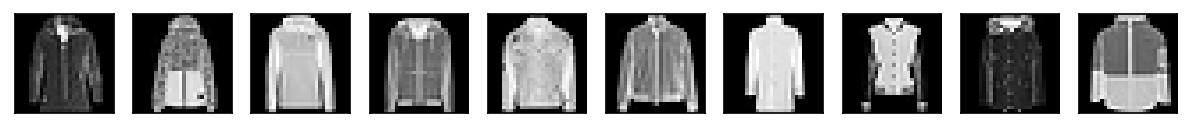

'label 5'

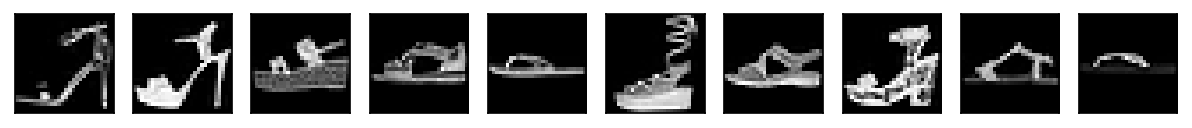

'label 6'

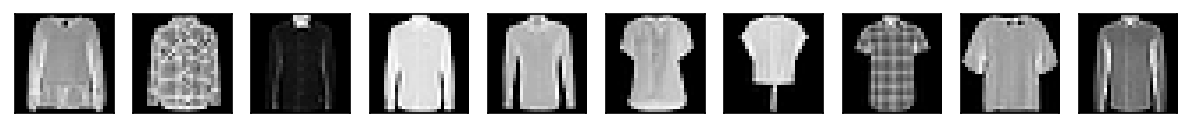

'label 7'

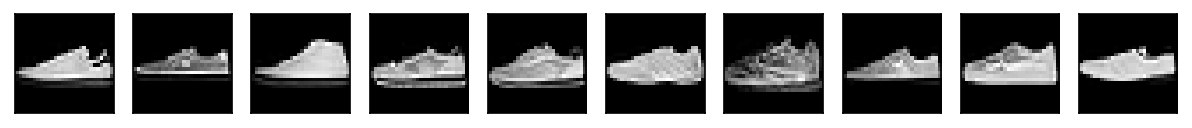

'label 8'

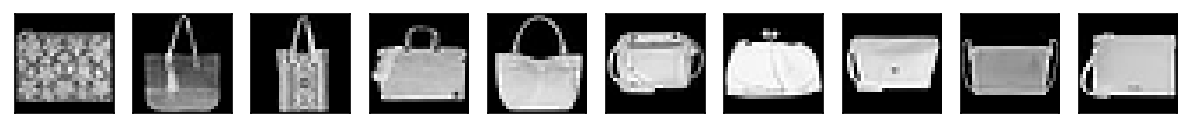

'label 9'

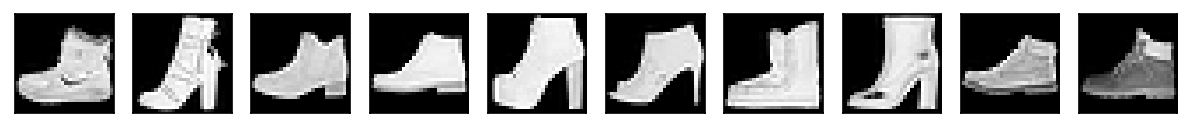

In [56]:
for label in range(10):
    display(f"label {label}")
    showLabel(label, n=10)

### Displays distribution and frequency of the data

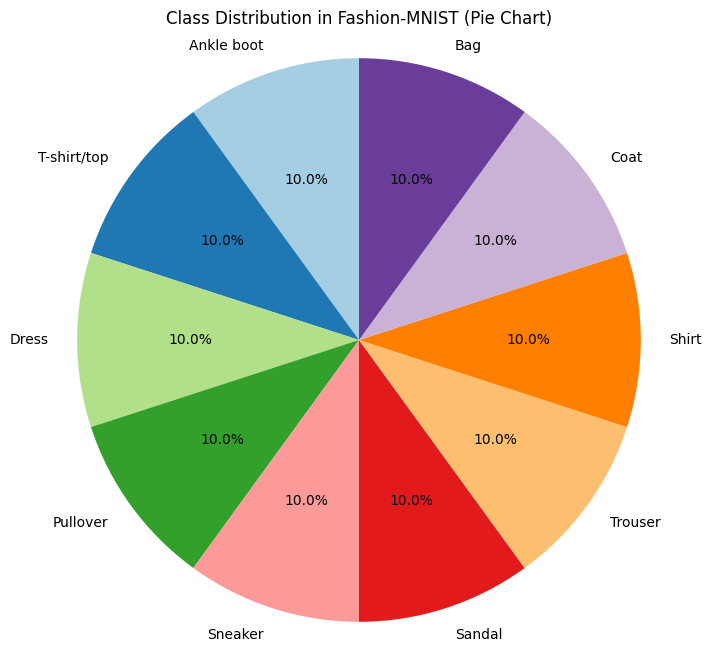

In [57]:
# List of class names for Fashion-MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

def pie_chart_class_distribution(labels):
    class_counts = Counter(labels)
    counts = list(class_counts.values())
    classes = [class_names[i] for i in class_counts.keys()]

    plt.figure(figsize=(8, 8))
    plt.pie(counts, labels=classes, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
    plt.title('Class Distribution in Fashion-MNIST (Pie Chart)')
    plt.axis('equal')
    plt.show()

# Distribution of train_lables
pie_chart_class_distribution(train_labels)

> The number of each layer is the same => **The dataset is balanced**

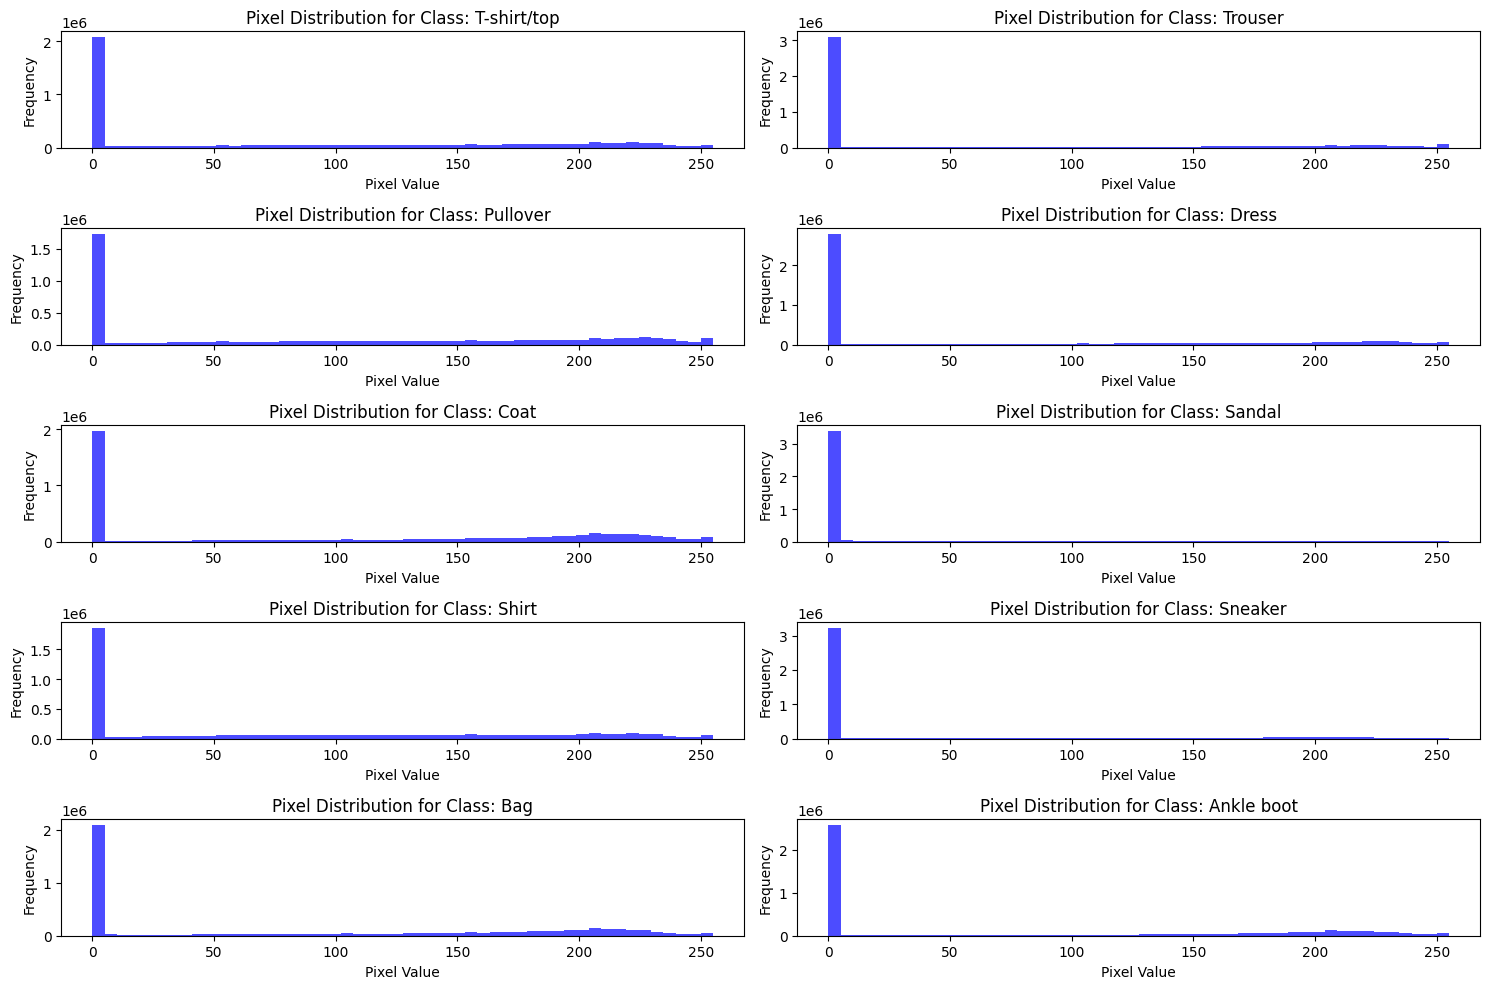

In [58]:
# Visualize distibution of each class
def plot_pixel_distribution_by_class(images, labels, class_names):
    plt.figure(figsize=(15, 10))

    for i in range(10):
        class_images = images[labels == i]
        class_images_flat = class_images.reshape(-1)

        plt.subplot(5, 2, i+1)
        plt.hist(class_images_flat, bins=50, color='blue', alpha=0.7)
        plt.title(f'Pixel Distribution for Class: {class_names[i]}')
        plt.xlabel('Pixel Value')
        plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

plot_pixel_distribution_by_class(train_images, train_labels, class_names)


>We can see **values .0** that are too dominant. So I adjust excluded_value to filter out other dominant pixel values such as 0 (representing black or background pixels) and plot again.

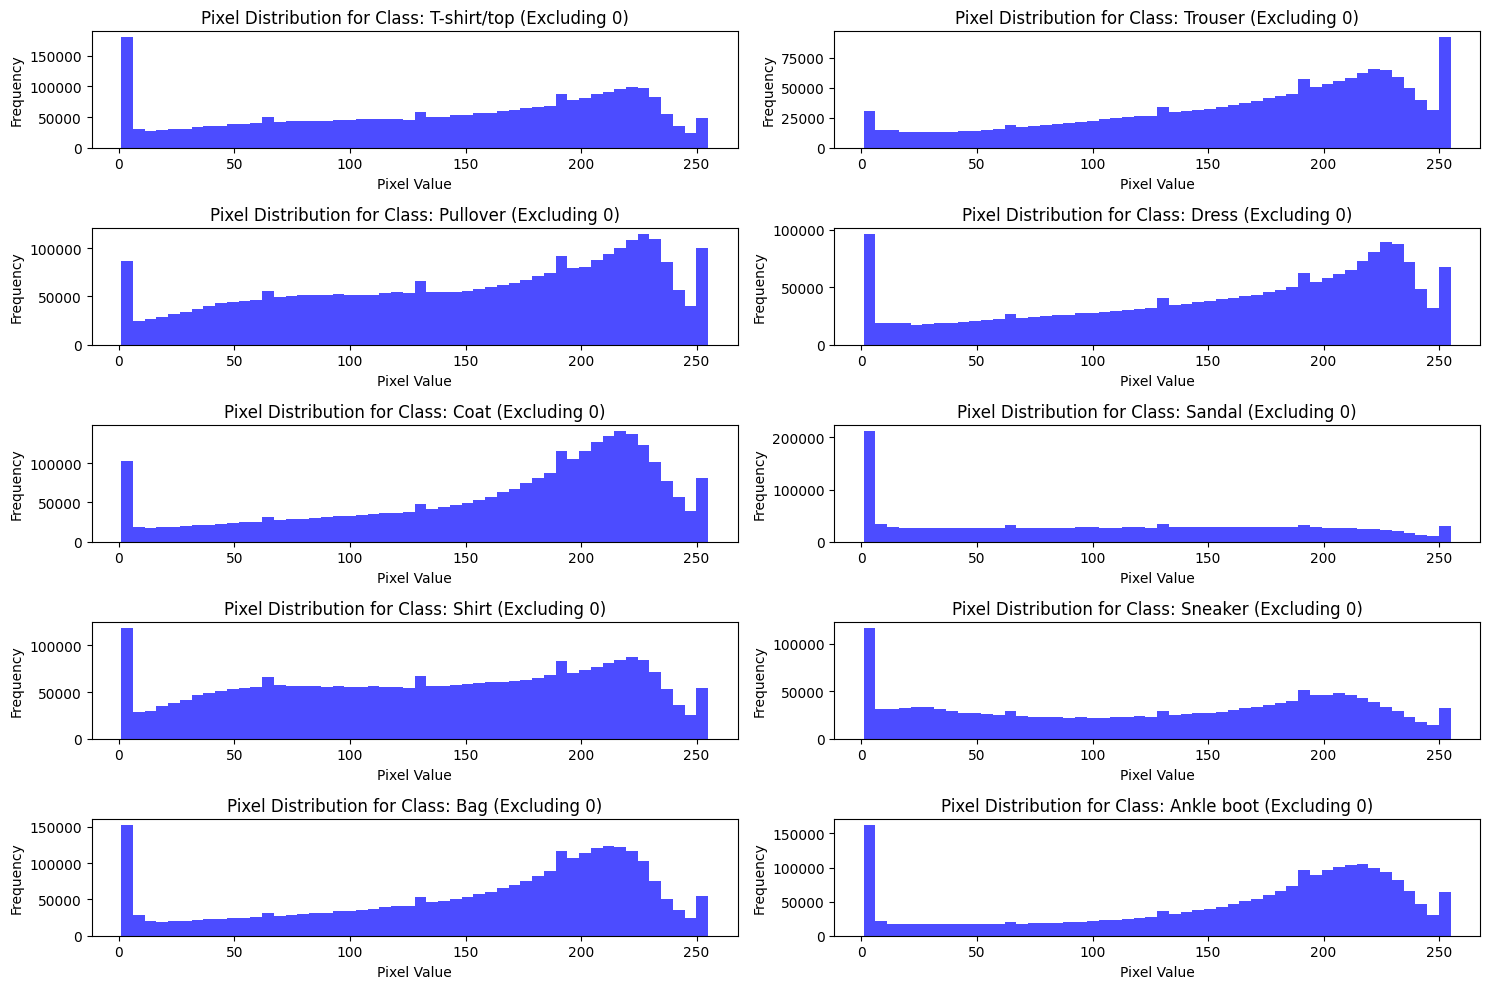

In [59]:
# Function to plot pixel intensity distribution for each class excluding certain pixel values
def plot_pixel_distribution_excluding_values(images, labels, class_names, excluded_value=0):
    plt.figure(figsize=(15, 10))

    for i in range(10):
        class_images = images[labels == i]
        class_images_flat = class_images.reshape(-1)

        # Exclude pixels with the given value (e.g., 0)
        class_images_filtered = class_images_flat[class_images_flat != excluded_value]

        plt.subplot(5, 2, i+1)
        plt.hist(class_images_filtered, bins=50, color='blue', alpha=0.7)
        plt.title(f'Pixel Distribution for Class: {class_names[i]} (Excluding {excluded_value})')
        plt.xlabel('Pixel Value')
        plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

plot_pixel_distribution_excluding_values(train_images, train_labels, class_names)

### Heat map for correlation label

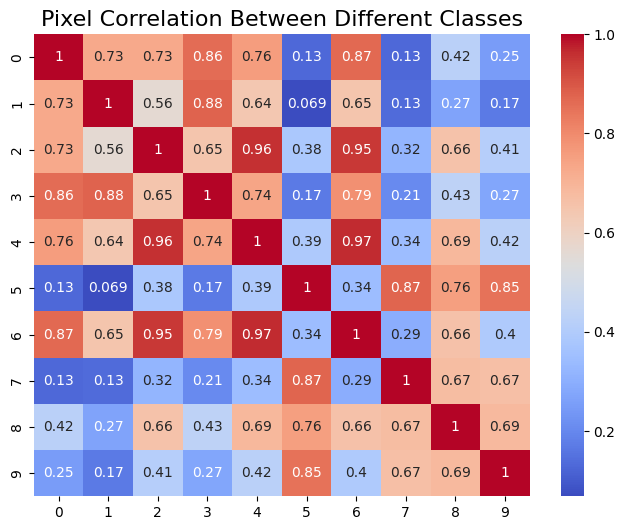

In [60]:
# Built correlation matrix

# Calculate the correlation matrix between classes
class_images = {label: [] for label in np.unique(train_labels)}
for i, label in enumerate(train_labels):
    class_images[label].append(train_images[i])

# Calculate the average image of each layer
mean_images = {label: np.mean(images, axis=0) for label, images in class_images.items()}

# Calculate the correlation matrix between classes
correlation_matrix = np.corrcoef([mean_image.flatten() for mean_image in mean_images.values()])

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", xticklabels=np.unique(train_labels), yticklabels=np.unique(train_labels))
plt.title("Pixel Correlation Between Different Classes", fontsize=16)
plt.show()

> The correlation coefficient of some classes is quite large => easily causes confusion, and reduces the performance of the model, especially logistic regression because the way this model operates is closely related to the correlation of the data of the classes.

# PREPROCESSING

In [61]:
from cuml.linear_model import LogisticRegression as cuMLLogisticRegression
from cuml.metrics import accuracy_score,confusion_matrix
from cuml.preprocessing import MinMaxScaler
import cupy as cp
import time

In [62]:
# Convert data from numpy array to cupy array to use GPU
train_images = cp.asarray(train_images)
train_labels = cp.asarray(train_labels,dtype=cp.int32)
test_images = cp.asarray(test_images)
test_labels = cp.asarray(test_labels, dtype=cp.int32)

In [63]:
# scale
scaler = MinMaxScaler()
train_images = scaler.fit_transform(train_images)
test_images = scaler.fit_transform(test_images)

# Model Training

* Method and Libraries: Use cuML instead of scikit-learn to enable GPU-accelerated training. As part of NVIDIA’s RAPIDS AI suite, cuML speeds up model training on large datasets by leveraging GPU power, which scikit-learn doesn’t support.

* Processing Unit: use GPU T4 x2 on Kaggle

## Linear Model - LogisticRegression

### Parameter

**solver: ‘qn’ (default=’qn’)**

> Algorithm to use in the optimization problem. Currently only qn is supported, which automatically selects either L-BFGS or OWL-QN depending on the conditions of the l1 regularization described above.

**max_iter: int (default = 1000)**

> Maximum number of iterations taken for the solvers to converge.

**penalty: ‘none’, ‘l1’, ‘l2’, ‘elasticnet’ (default = ‘l2’)**

> Used to specify the norm used in the penalization. If ‘none’ or ‘l2’ are selected, then L-BFGS solver will be used. If ‘l1’ is selected, solver OWL-QN will be used. If ‘elasticnet’ is selected, OWL-QN will be used if l1_ratio > 0, otherwise L-BFGS will be used.

**fit_intercept: boolean (default = True)**

> If True, the model tries to correct for the global mean of y. If False, the model expects that you have centered the data.

**C: float (default = 1.0)**

> Inverse of regularization strength; must be a positive float

### Softmax Regression

cuML’s LogisticRegression can take array-like objects, either in host as NumPy arrays or in device (as Numba or __cuda_array_interface__ compliant), in addition to cuDF objects. It provides both single-class (using sigmoid loss) and multiple-class (using softmax loss) variants, depending on the input variables.

In [64]:
# Train Logistic Regression with multiple-class (Softmax Regression) 
softmax_model = cuMLLogisticRegression(max_iter=3000, solver='qn', fit_intercept=True) # multiple-class (using softmax loss) variants, depending on the input variables

start_time = time.time()
softmax_model.fit(train_images, train_labels)
end_time = time.time()

# calculate training time
softmax_training_time = end_time - start_time

Training time: 75.47s
Accuracy: 0.8443
Precision: 0.8431
Recall: 0.8443
F1 Score: 0.8434


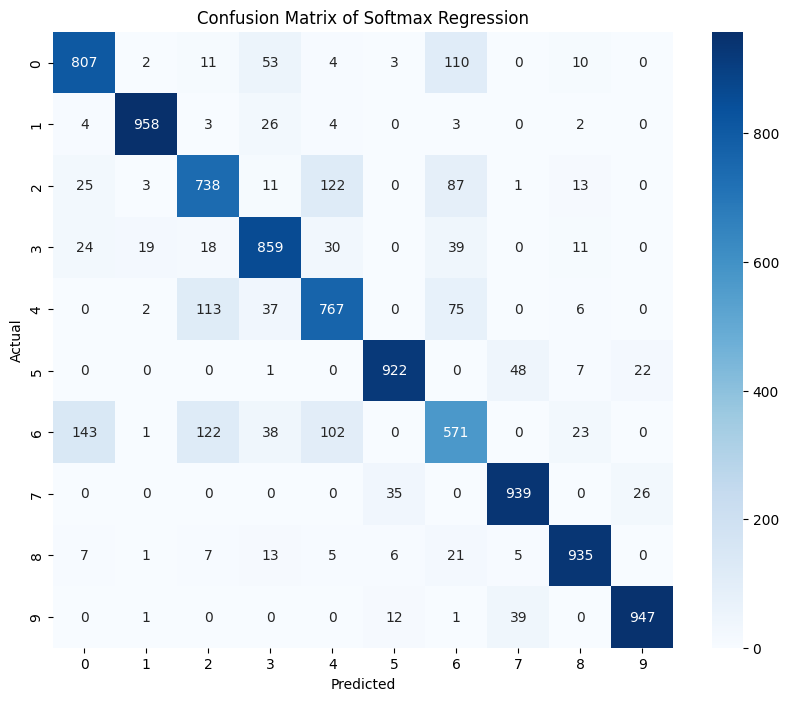

In [65]:
# Make predict on test-set
test_predictions = softmax_model.predict(test_images)
pred_softmax = test_predictions

# Evaluate softmax Regression model
softmax_accuracy = accuracy_score(test_labels, test_predictions)
softmax_precision = precision_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
softmax_recall = recall_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
softmax_f1 = f1_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')

print(f"Training time: {softmax_training_time:.2f}s")
print(f"Accuracy: {softmax_accuracy:.4f}")
print(f"Precision: {softmax_precision:.4f}")
print(f"Recall: {softmax_recall:.4f}")
print(f"F1 Score: {softmax_f1:.4f}")

# confusion matrix
softmax_conf_matrix = confusion_matrix(test_labels, test_predictions)
softmax_conf_matrix = cp.asnumpy(softmax_conf_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(softmax_conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of Softmax Regression')
plt.show()

#### Observation from score
* The accuracy of the model is 84.40%, which means the model correctly predicts 84.40% of the samples in the test set. This is a pretty good result, indicating that the model is quite accurate in classifying the classes.
* The precision is 84.28%, meaning that 84.28% of the model's positive predictions are correct.
* The recall is 84.40%, meaning the model can identify 84.40% of the actual positive samples from all the positive samples.
* The F1 Score is 84.32%, which is the harmonic mean of precision and recall. The high value of the F1 Score (84.32%) indicates that the model performs well on both aspects.

 #### Observation from confusion matrix

In [66]:
# Filter and print classes with correctly classified samples >= 900
for class_idx in range(softmax_conf_matrix.shape[0]):
    correct_predictions = softmax_conf_matrix[class_idx, class_idx]
    if correct_predictions >= 900:
        print(f"Class '{class_names[class_idx]}' has {correct_predictions} correctly classified samples.")

Class 'Trouser' has 958 correctly classified samples.
Class 'Sandal' has 922 correctly classified samples.
Class 'Sneaker' has 939 correctly classified samples.
Class 'Bag' has 935 correctly classified samples.
Class 'Ankle boot' has 947 correctly classified samples.


Class **'Trouser', 'Sandal', 'Sneaker', 'Bag', 'Ankle'** have high accuracy with over 900 correct predictions and minimal misclassifications.

In [67]:
# Filter and print class pairs with more than 100 misclassified samples, using class names 
for actual_class in range(softmax_conf_matrix.shape[0]):
    for predicted_class in range(softmax_conf_matrix.shape[1]):
        if actual_class != predicted_class and softmax_conf_matrix[actual_class, predicted_class] > 100:
            print(f"Actual class '{class_names[actual_class]}' misclassified as '{class_names[predicted_class]}': {softmax_conf_matrix[actual_class, predicted_class]} samples")

Actual class 'T-shirt/top' misclassified as 'Shirt': 110 samples
Actual class 'Pullover' misclassified as 'Coat': 122 samples
Actual class 'Coat' misclassified as 'Pullover': 113 samples
Actual class 'Shirt' misclassified as 'T-shirt/top': 143 samples
Actual class 'Shirt' misclassified as 'Pullover': 122 samples
Actual class 'Shirt' misclassified as 'Coat': 102 samples


**There are 4 pairs of classes that are easily confused:**
* 'T-shirt/top' vs 'Shirt'
* 'Pullover' vs 'Coat'
* 'Shirt' vs 'Pullover'
* 'Shirt' vs 'Coat'


### Logistic Regression (One vs Rest)

Với Logistic Regression ta sẽ có 2 chiến thuật để phân loại dữ liệu đa nhãn dán:

- One-Vs-One : Tức là với mỗi 2 lớp khác nhau, ta sẽ tạo một phân lớp nhị phân cho 2 lớp đó rồi bỏ phiếu cho lớp chiến thắng. Sau cùng ta chọn lớp có nhiều phiếu nhất để làm lớp dự đoán cho điểm dữ liệu.
    - Với chiếc thuật này sẽ giúp giảm phân nhóm sai vì so sánh từng lớp. Nhưng cùng với đó sẽ phải tạo ra rất nhiều bộ phân lớp và tồn tại các phân lớp thừa.
- One-Vs-Rest: Ta sẽ tạo ra các phân lớp giữa 1 lớp và tất cả các lớp còn lại, sau đó ta chọn lớp có xác suất lớn nhất để làm lớp cho điểm dữ liệu.
    - Chiến thuật này sẽ giảm lại số phân lớp , độ phức tạp tính toán cũng giảm. Tuy nhiên sẽ gây ra kết quả xấu nếu số lượng của các nhãn dán quá chênh lệch nhau đồng thời gây sẽ phân nhóm sai nếu các điểm dữ liệu không tách với phần còn lại một cách rõ ràng

In [68]:
from cuml.multiclass import OneVsOneClassifier, OneVsRestClassifier

Training time :  21.005
Accuracy : 0.8410999774932861
Precision score : 0.8389922636558321 
Recall score: 0.8411
F1 score : 0.8394161031492351 


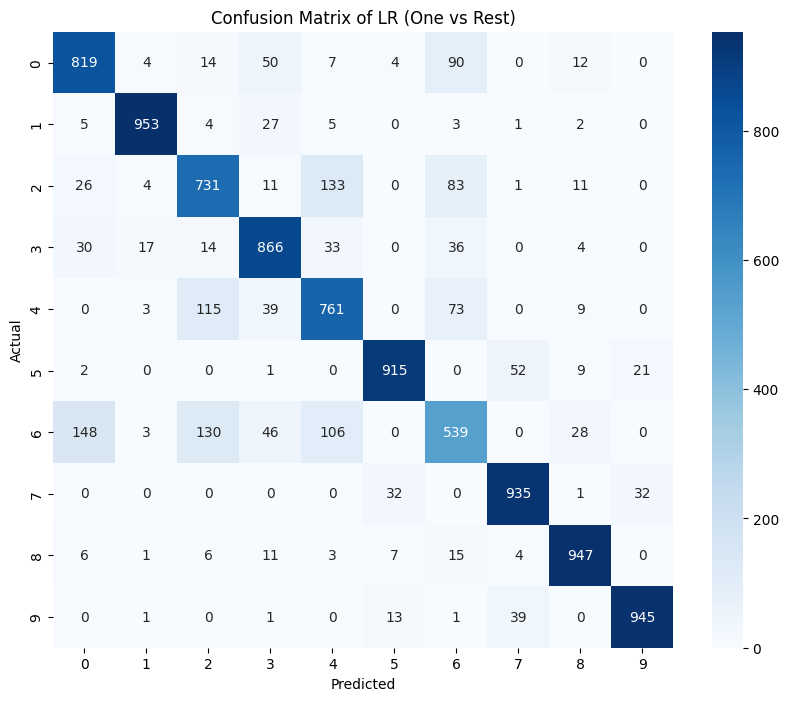

In [69]:
ovr_model=OneVsRestClassifier(cuMLLogisticRegression(max_iter=3000))


start=time.time()
ovr_model.fit(train_images, train_labels)
ovr_training_time =time.time()-start

preds = ovr_model.predict(test_images)
pred_ovr = preds

ovr_accuracy = accuracy_score(test_labels,preds)
ovr_precision = precision_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')
ovr_recall = recall_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')
ovr_f1_score = f1_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')


print(f"Training time : {ovr_training_time : .3f}")
print(f"Accuracy : {ovr_accuracy}")
print(f"Precision score : {ovr_precision:} " )
print(f"Recall score: {ovr_recall}")
print(f"F1 score : {ovr_f1_score} ")

# Confusion matrix
ovr_conf_matrix = confusion_matrix(test_labels.astype('int32'),preds)
ovr_conf_matrix = cp.asnumpy(ovr_conf_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(ovr_conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of LR (One vs Rest)')
plt.show()

#### Observation from confusion matrix

In [70]:
# Filter and print classes with correctly classified samples >= 900
for class_idx in range(ovr_conf_matrix.shape[0]):
    correct_predictions = ovr_conf_matrix[class_idx, class_idx]
    if correct_predictions >= 900:
        print(f"Class '{class_names[class_idx]}' has {correct_predictions} correctly classified samples.")

Class 'Trouser' has 953 correctly classified samples.
Class 'Sandal' has 915 correctly classified samples.
Class 'Sneaker' has 935 correctly classified samples.
Class 'Bag' has 947 correctly classified samples.
Class 'Ankle boot' has 945 correctly classified samples.


Class **'Trouser', 'Sandal', 'Sneaker', 'Bag', 'Ankle'** have high accuracy with over 900 correct predictions and minimal misclassifications. (almost similar to sofrmax model)

In [71]:
# Filter and print class pairs with more than 100 misclassified samples, using class names 
for actual_class in range(ovr_conf_matrix.shape[0]):
    for predicted_class in range(ovr_conf_matrix.shape[1]):
        if actual_class != predicted_class and softmax_conf_matrix[actual_class, predicted_class] > 100:
            print(f"Actual class '{class_names[actual_class]}' misclassified as '{class_names[predicted_class]}': {softmax_conf_matrix[actual_class, predicted_class]} samples")

Actual class 'T-shirt/top' misclassified as 'Shirt': 110 samples
Actual class 'Pullover' misclassified as 'Coat': 122 samples
Actual class 'Coat' misclassified as 'Pullover': 113 samples
Actual class 'Shirt' misclassified as 'T-shirt/top': 143 samples
Actual class 'Shirt' misclassified as 'Pullover': 122 samples
Actual class 'Shirt' misclassified as 'Coat': 102 samples


**There are 4 pairs of classes that are easily confused:**
* 'T-shirt/top' vs 'Shirt'
* 'Pullover' vs 'Coat'
* 'Shirt' vs 'Pullover'
* 'Shirt' vs 'Coat'

Similar to the softmax model

### Logistic Regression (One vs One)

Training time :  15.065
Accuracy : 0.8500999808311462
Precision score : 0.8488166553865915 
Recall score: 0.8501
F1 score : 0.8493495758434614 


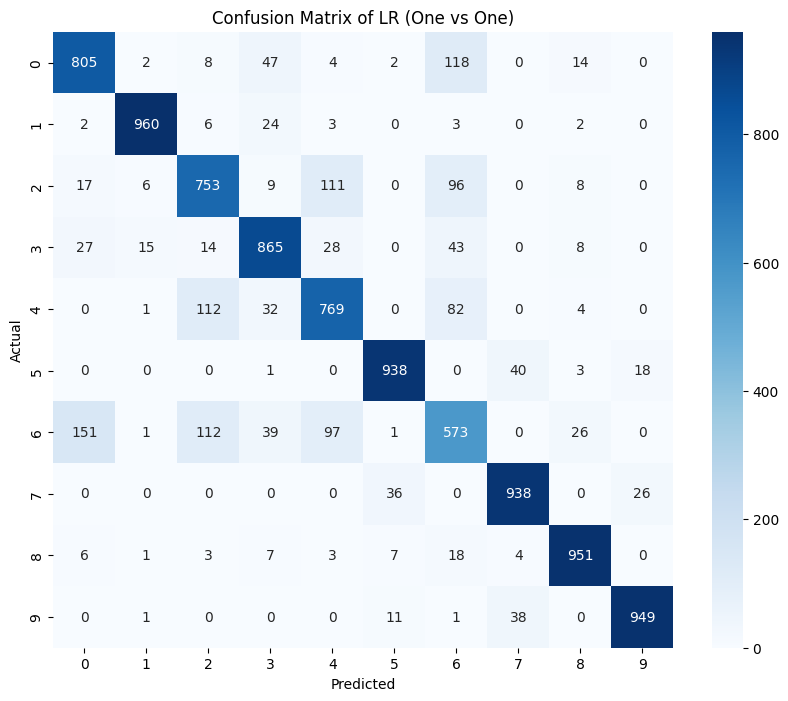

In [72]:
ovo_model=OneVsOneClassifier(cuMLLogisticRegression(max_iter=3000))


start=time.time()
ovo_model.fit(train_images, train_labels)
ovo_training_time =time.time()-start

preds =ovo_model.predict(test_images)
pred_ovo = preds

ovo_accuracy = accuracy_score(test_labels,preds)
ovo_precision = precision_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')
ovo_recall = recall_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')
ovo_f1_score = f1_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')


print(f"Training time : {ovo_training_time : .3f}")
print(f"Accuracy : {ovo_accuracy}")
print(f"Precision score : {ovo_precision:} " )
print(f"Recall score: {ovo_recall}")
print(f"F1 score : {ovo_f1_score} ")

# Confusion matrix
ovo_conf_matrix = confusion_matrix(test_labels.astype('int32'),preds)
ovo_conf_matrix = cp.asnumpy(ovo_conf_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(ovo_conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of LR (One vs One)')
plt.show()

#### Observation from score

#### **Observation from confusion matrix**


In [73]:
# Filter and print classes with correctly classified samples >= 900
for class_idx in range(ovo_conf_matrix.shape[0]):
    correct_predictions = ovo_conf_matrix[class_idx, class_idx]
    if correct_predictions >= 900:
        print(f"Class '{class_names[class_idx]}' has {correct_predictions} correctly classified samples.")

Class 'Trouser' has 960 correctly classified samples.
Class 'Sandal' has 938 correctly classified samples.
Class 'Sneaker' has 938 correctly classified samples.
Class 'Bag' has 951 correctly classified samples.
Class 'Ankle boot' has 949 correctly classified samples.


Class **'Trouser', 'Sandal', 'Sneaker', 'Bag', 'Ankle'** have high accuracy with over 900 correct predictions and minimal misclassifications. (similar to the softmax regression model)

In [74]:
# Filter and print class pairs with more than 100 misclassified samples, using class names 
for actual_class in range(ovo_conf_matrix.shape[0]):
    for predicted_class in range(ovo_conf_matrix.shape[1]):
        if actual_class != predicted_class and ovo_conf_matrix[actual_class, predicted_class] > 100:
            print(f"Actual class '{class_names[actual_class]}' misclassified as '{class_names[predicted_class]}': {softmax_conf_matrix[actual_class, predicted_class]} samples")

Actual class 'T-shirt/top' misclassified as 'Shirt': 110 samples
Actual class 'Pullover' misclassified as 'Coat': 122 samples
Actual class 'Coat' misclassified as 'Pullover': 113 samples
Actual class 'Shirt' misclassified as 'T-shirt/top': 143 samples
Actual class 'Shirt' misclassified as 'Pullover': 122 samples


**There are 4 pairs of classes that are easily confused:**
* 'T-shirt/top' vs 'Shirt'
* 'Pullover' vs 'Coat'
* 'Shirt' vs 'Pullover'

Confusion between 'Shirt' and 'Coat' is reduced compared to the previous model (96)

### Comparision

In [75]:
data = {
    'Model': ['Softmax', 'OVR', 'OVO'],
    'Training Time (s)': [softmax_training_time, ovr_training_time, ovo_training_time],
    'Accuracy': [softmax_accuracy, ovr_accuracy, ovo_accuracy],
    'Precision': [softmax_precision, ovr_precision, ovo_precision],
    'Recall': [softmax_recall, ovr_recall, ovo_recall],
    'F1 Score': [softmax_f1, ovr_f1_score, ovo_f1_score]
}

LR_df = pd.DataFrame(data)

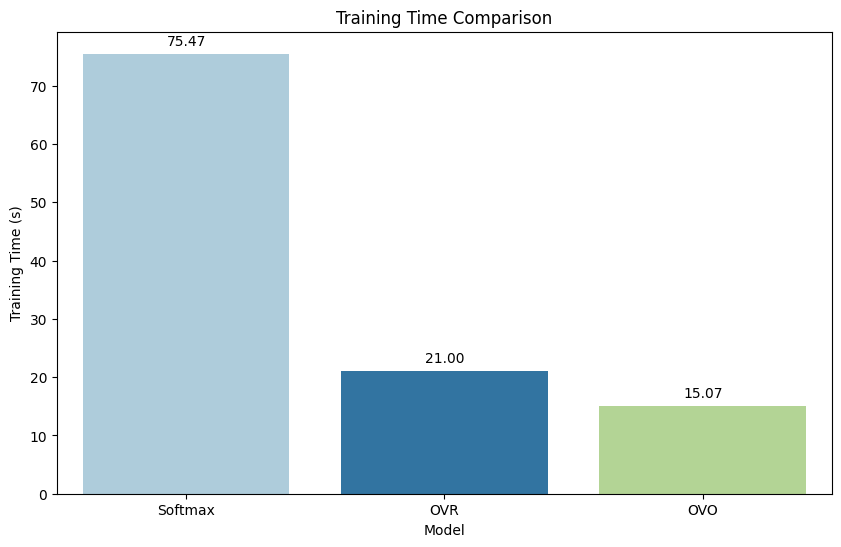

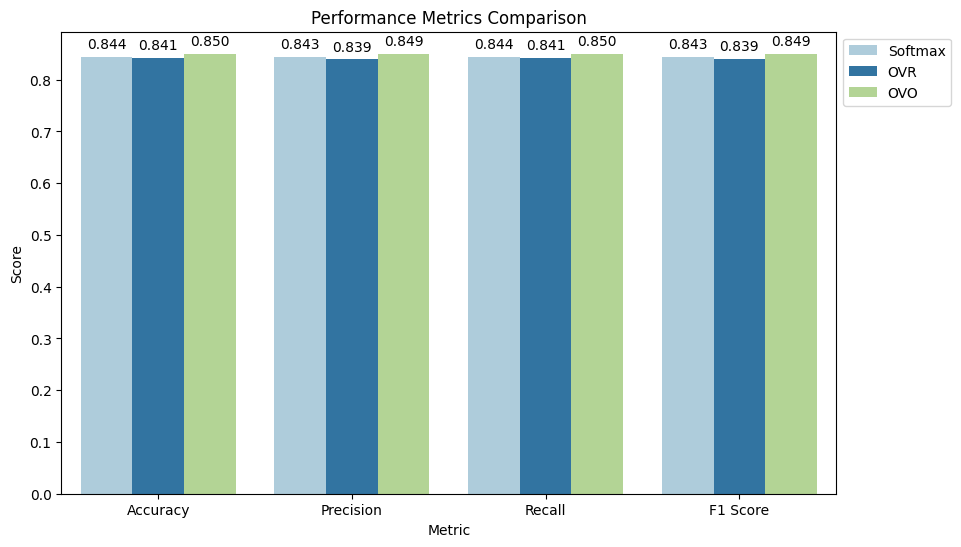

In [76]:
custom_palette = sns.color_palette("Paired", as_cmap=False)  # "viridis" is a gradient palette
sns.set_palette(custom_palette)

# Plotting training time comparison
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='Training Time (s)', data=LR_df)
plt.title('Training Time Comparison')

# Hiển thị giá trị trên cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')
plt.show()

# Plotting performance metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
df_melted = LR_df.melt(id_vars=['Model'], value_vars=metrics, var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Metric', y='Score', hue='Model', data=df_melted)
plt.title('Performance Metrics Comparison')

# Hiển thị giá trị trên cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')
    
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

OVO rõ ràng là model hiệu quả nhất khi xét về cả thời gian huấn luyện và các chỉ số hiệu suất (accuracy, precision, recall, F1 score).

Softmax có thời gian huấn luyện lâu nhất, nhưng kết quả hiệu suất cũng không quá xuất sắc so với OVO.

OVR mặc dù có thời gian huấn luyện nhanh hơn Softmax, nhưng vẫn kém hiệu quả hơn OVO về các chỉ số hiệu suất.

Với các kết quả này, OVO có vẻ là lựa chọn tốt nhất cho bài toán phân loại của bạn khi cần tối ưu cả về thời gian và hiệu suất mô hình.

## Support Vector Machine (SVM)

### Paramater

**penalty: {‘l1’, ‘l2’} (default = ‘l2’)**
>The regularization term of the target function.

**loss:{‘squared_hinge’, ‘hinge’} (default = ‘squared_hinge’)**
>The loss term of the target function.

**fit_intercept: bool (default = True)**
>Whether to fit the bias term. Set to False if you expect that the data is already centered.

**penalized_intercept: bool (default = False)**
>When true, the bias term is treated the same way as other features; i.e. it’s penalized by the regularization term of the target function. Enabling this feature forces an extra copying the input data X.

**max_iter: int (default = 1000)**
>Maximum number of iterations for the underlying solver.

**linesearch_max_iter: int (default = 100)**
>Maximum number of linesearch (inner loop) iterations for the underlying (QN) solver.

**lbfgs_memory: int (default = 5)**
>Number of vectors approximating the hessian for the underlying QN solver (l-bfgs).

**C: float (default = 1.0)**
>The constant scaling factor of the loss term in the target formula:  *F(X, y) = penalty(X) + C * loss(X, y).*

>C is a parameter that adjusts the model's strictness regarding misclassified data points.

> C balances the trade-off between the model's accuracy on the training set and its ability to generalize.
 
**Gamma (RBF kernel):**
>affects how data points influence each other in the feature space.

>Gamma adjusts the complexity of the decision boundary in the feature space.

### Linear Kernel

In [77]:
from cuml.svm import LinearSVC

In [78]:
# Training SVM witth linear kernel model
svc_linear_model = LinearSVC(C=0.1) # with C = 0.1, model has the best performance

start_time = time.time()
svc_linear_model.fit(train_images, train_labels)
end_time = time.time()

# Calculate training time
svc_linear_training_time = end_time - start_time

Training time: 3.59s
Accuracy: 0.8424
Precision: 0.8397
Recall: 0.8424
F1 Score: 0.8400


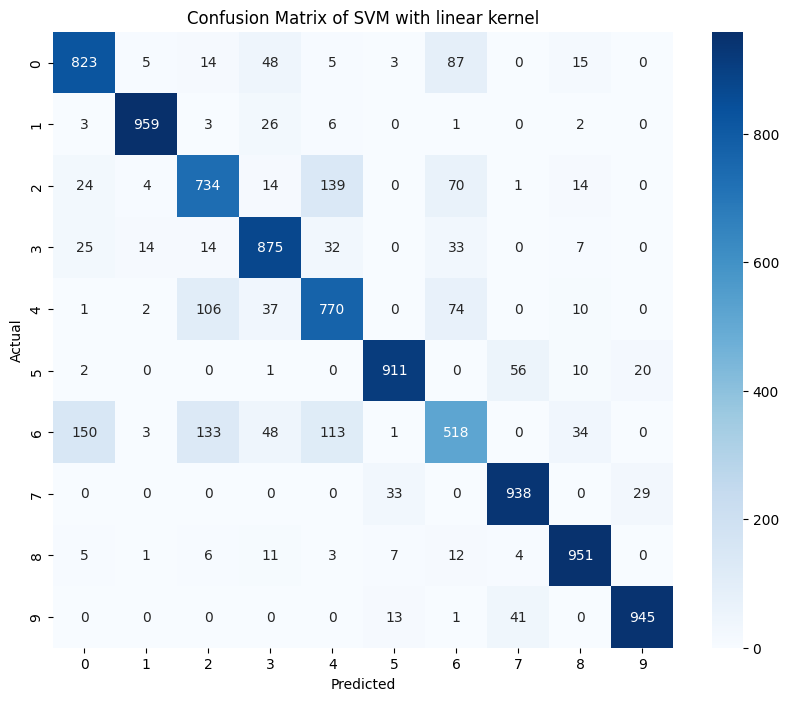

In [79]:
# Make predictions
test_predictions = svc_linear_model.predict(test_images)
pred_svc_linear = test_predictions

# Evaluate Support Vector Machine model with linear kernel
svc_linear_accuracy = accuracy_score(test_labels, test_predictions)
svc_linear_precision = precision_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
svc_linear_recall = recall_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
svc_linear_f1 = f1_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')

print(f"Training time: {svc_linear_training_time:.2f}s")
print(f"Accuracy: {svc_linear_accuracy:.4f}")
print(f"Precision: {svc_linear_precision:.4f}")
print(f"Recall: {svc_linear_recall:.4f}")
print(f"F1 Score: {svc_linear_f1:.4f}")

test_predictions = test_predictions.astype('int32')
# Confusion Matrix
svc_linear_conf_matrix = confusion_matrix(test_labels, test_predictions)
svc_linear_conf_matrix = cp.asnumpy(svc_linear_conf_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(svc_linear_conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of SVM with linear kernel')
plt.show()

#### Observation from score
* Accuracy: 0.8428: The model predicts correctly 84.28% of the test samples. This is a good result, especially if the data is not imbalanced or has rare classes (we have balanced data on test set)

* Precision: 0.8403: 84.03% of the predicted positive samples are true positives. This indicates the model effectively distinguishes between classes and has a low false positive rate.

* Recall: 0.8428: The model correctly identifies 84.28% of the actual positive samples, showing it does not miss many true positives.

* F1 Score: 0.8404: The F1 Score, the harmonic mean of Precision and Recall, is 84.04%. This reflects a good balance between Precision and Recall

#### Observation from confusion matrix

In [80]:
# Filter and print classes with correctly classified samples >= 900
for class_idx in range(svc_linear_conf_matrix.shape[0]):
    correct_predictions = svc_linear_conf_matrix[class_idx, class_idx]
    if correct_predictions >= 900:
        print(f"Class '{class_names[class_idx]}' has {correct_predictions} correctly classified samples.")

Class 'Trouser' has 959 correctly classified samples.
Class 'Sandal' has 911 correctly classified samples.
Class 'Sneaker' has 938 correctly classified samples.
Class 'Bag' has 951 correctly classified samples.
Class 'Ankle boot' has 945 correctly classified samples.


Class **'Trouser', 'Sandal', 'Sneaker', 'Bag', 'Ankle'** have high accuracy with over 900 correct predictions and minimal misclassifications.

In [81]:
# Filter and print class pairs with more than 100 misclassified samples, using class names 
for actual_class in range(svc_linear_conf_matrix.shape[0]):
    for predicted_class in range(svc_linear_conf_matrix.shape[1]):
        if actual_class != predicted_class and svc_linear_conf_matrix[actual_class, predicted_class] > 100:
            print(f"Actual class '{class_names[actual_class]}' misclassified as '{class_names[predicted_class]}': {svc_linear_conf_matrix[actual_class, predicted_class]} samples")

Actual class 'Pullover' misclassified as 'Coat': 139 samples
Actual class 'Coat' misclassified as 'Pullover': 106 samples
Actual class 'Shirt' misclassified as 'T-shirt/top': 150 samples
Actual class 'Shirt' misclassified as 'Pullover': 133 samples
Actual class 'Shirt' misclassified as 'Coat': 113 samples


**There are 4 pairs of classes that are easily confused:**
* 'Pullover' vs 'Coat'
* 'Shirt' vs 'Coat'
* 'Shirt' vs 'Pullover'
* 'Shirt' vs 'T-shirt/top'

### RBF kernel

In [82]:
from cuml.svm import SVC

In [83]:
# Training SVM with RBF model
svc_RBF_model = SVC(kernel='rbf', gamma='scale', C=10) # with gamma = 'scale', C = 10, model has the best performance

start_time = time.time()
svc_RBF_model.fit(train_images, train_labels)
end_time = time.time()

# Time for training model
svc_RBF_training_time = end_time - start_time

Training time: 21.64s
Accuracy: 0.9015
Precision: 0.9014
Recall: 0.9015
F1 Score: 0.9014


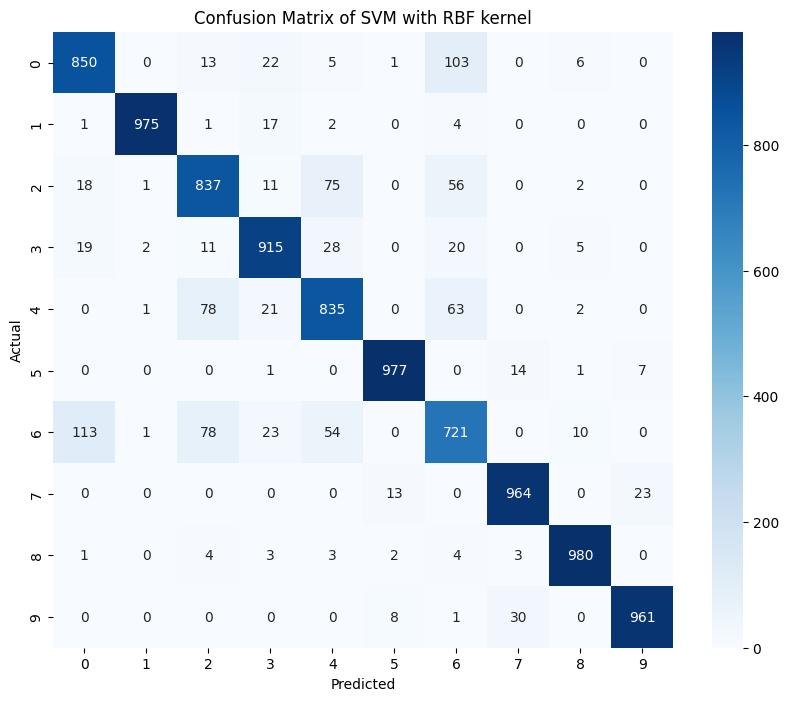

In [84]:
# Make predictions on test set
test_predictions = svc_RBF_model.predict(test_images)
pred_svc_rbf = test_predictions

# Evaluate Support Vector Machine model with rbf kernel
svc_RBF_accuracy = accuracy_score(test_labels, test_predictions)
svc_RBF_precision = precision_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
svc_RBF_recall = recall_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
svc_RBF_f1 = f1_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')

print(f"Training time: {svc_RBF_training_time:.2f}s")
print(f"Accuracy: {svc_RBF_accuracy:.4f}")
print(f"Precision: {svc_RBF_precision:.4f}")
print(f"Recall: {svc_RBF_recall:.4f}")
print(f"F1 Score: {svc_RBF_f1:.4f}")

# Confusion Matrix
svc_RBF_conf_matrix = confusion_matrix(test_labels, test_predictions)
svc_RBF_conf_matrix = cp.asnumpy(svc_RBF_conf_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(svc_RBF_conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of SVM with RBF kernel')
plt.show()

#### Observation from score

* Accuracy: 0.9015: An accuracy of 90.15% means the model correctly predicts 90.15% of the test samples. This is an excellent result, especially if the data is not imbalanced or has rare classes. The model demonstrates outstanding performance and high classification accuracy.

* Precision: 0.9014:With a precision of 90.14%, 90.14% of the samples predicted as positive are actually positive (true positive + false positive). This indicates the model has an excellent ability to distinguish between classes and has a low false positive rate. Maintaining this level of precision is a positive sign of the model's effectiveness.

* Recall: 0.9015:The recall rate is 90.15%, meaning the model correctly identifies 90.15% of the actual positive samples (true positive + false negative). This shows that the model is not only accurate but also highly effective at detecting positive samples, minimizing the number of true positives that are missed. This is a commendable achievement.

* F1 Score: 0.9014: An F1 Score of 90.14%, the harmonic mean of Precision and Recall, indicates an excellent balance between these two metrics. A high F1 Score demonstrates that the model not only achieves high accuracy but also has a consistent ability to detect and classify positive samples. This is especially important in real-world applications where both precision and recall are crucial.

#### Observation from confusion matrix

In [85]:
# Filter and print classes with correctly classified samples >= 900
for class_idx in range(svc_RBF_conf_matrix.shape[0]):
    correct_predictions = svc_RBF_conf_matrix[class_idx, class_idx]
    if correct_predictions >= 900:
        print(f"Class '{class_names[class_idx]}' has {correct_predictions} correctly classified samples.")

Class 'Trouser' has 975 correctly classified samples.
Class 'Dress' has 915 correctly classified samples.
Class 'Sandal' has 977 correctly classified samples.
Class 'Sneaker' has 964 correctly classified samples.
Class 'Bag' has 980 correctly classified samples.
Class 'Ankle boot' has 961 correctly classified samples.


Class **'Trouser', 'Dress', 'Sandal', 'Sneaker', 'Bag', 'Ankle'** have high accuracy with over 900 correct predictions and minimal misclassifications. Notably, the inclusion of **'Dress'** shows improved performance compared to other models, indicating that the model is effectively distinguishing this class as well.

In [86]:
# Filter and print class pairs with more than 100 misclassified samples, using class names 
for actual_class in range(svc_RBF_conf_matrix.shape[0]):
    for predicted_class in range(svc_RBF_conf_matrix.shape[1]):
        if actual_class != predicted_class and svc_RBF_conf_matrix[actual_class, predicted_class] > 100:
            print(f"Actual class '{class_names[actual_class]}' misclassified as '{class_names[predicted_class]}': {svc_RBF_conf_matrix[actual_class, predicted_class]} samples")

Actual class 'T-shirt/top' misclassified as 'Shirt': 103 samples
Actual class 'Shirt' misclassified as 'T-shirt/top': 113 samples


**There is only 1 pairs of classes that are easily confused:**
* 'T-shirt/top' vs 'Shirt'

In [87]:
# Creating a dataframe with the results
data = {
    'Kernel': ['Linear', 'RBF'],
    'Training Time (s)': [svc_linear_training_time, svc_RBF_training_time],
    'Accuracy': [svc_linear_accuracy, svc_RBF_accuracy],
    'Precision': [svc_linear_precision, svc_RBF_precision],
    'Recall': [svc_linear_recall, svc_RBF_recall],
    'F1 Score': [svc_linear_f1, svc_RBF_f1]
}
SVM_df = pd.DataFrame(data)

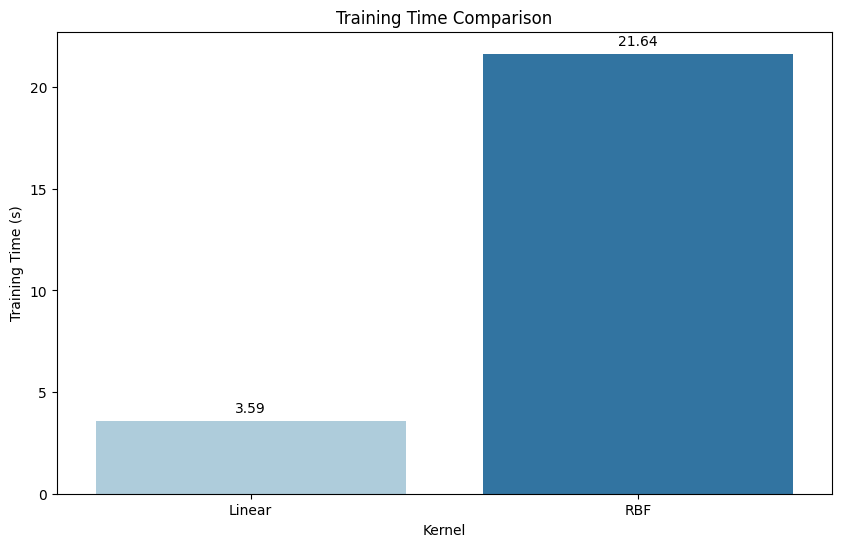

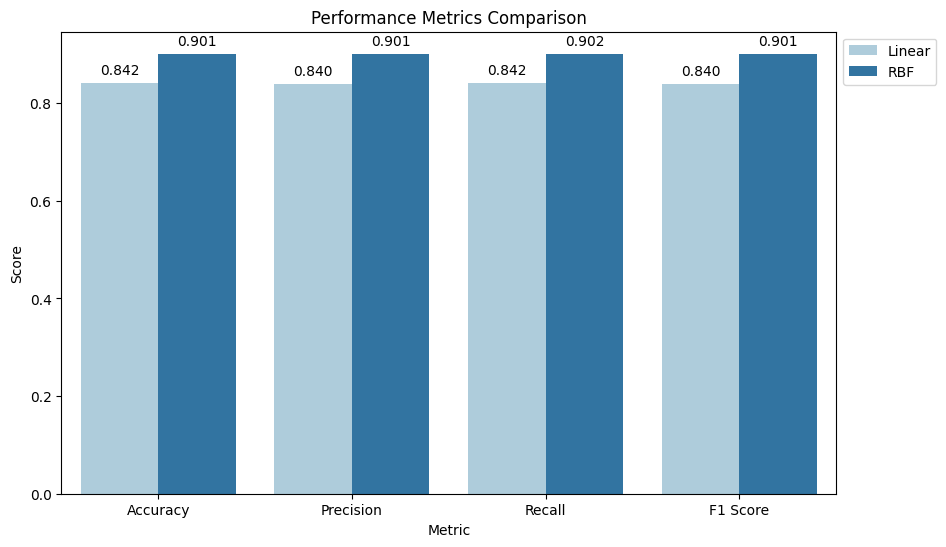

In [88]:
custom_palette = sns.color_palette("Paired", as_cmap=False)  # "viridis" is a gradient palette
sns.set_palette(custom_palette)

# Plotting training time comparison
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Kernel', y='Training Time (s)', data=SVM_df)
plt.title('Training Time Comparison')

# Hiển thị giá trị trên cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')
plt.show()

# Plotting performance metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
df_melted = SVM_df.melt(id_vars=['Kernel'], value_vars=metrics, var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Metric', y='Score', hue='Kernel', data=df_melted)
plt.title('Performance Metrics Comparison')

# Hiển thị giá trị trên cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

Linear Kernel có thời gian huấn luyện nhanh hơn rất nhiều so với RBF kernel. Điều này có thể là do kernel tuyến tính chỉ cần tính toán đường phân cách tuyến tính giữa các lớp, trong khi RBF kernel phải thực hiện các phép toán phi tuyến để phân tách các lớp dữ liệu phức tạp hơn.

Các chỉ số của RBF kernel đều cao hơn kernel tuyến tính, cho thấy RBF kernel có khả năng phân loại tốt hơn và hiệu quả hơn trong việc xử lý các mẫu phức tạp. ta thấy được RBF kernel có hiệu suất tốt hơn về mọi mặt (độ chính xác, độ chính xác, tỷ lệ hồi lại, điểm F1), phù hợp cho các ứng dụng yêu cầu độ chính xác cao hơn.

# Model evaluation

In [89]:
data = {
    'Model': ['Softmax', 'OVR', 'OVO', 'Linear kernel SVM', 'RBF kernel SVM'],
    'Training Time (s)': [softmax_training_time, ovr_training_time, ovo_training_time, svc_linear_training_time, svc_RBF_training_time, ],
    'Accuracy': [softmax_accuracy, ovr_accuracy, ovo_accuracy,svc_linear_accuracy, svc_RBF_accuracy ],
    'Precision': [softmax_precision, ovr_precision, ovo_precision,svc_linear_precision, svc_RBF_precision ],
    'Recall': [softmax_recall, ovr_recall, ovo_recall,svc_linear_recall, svc_RBF_recall ],
    'F1 Score': [softmax_f1, ovr_f1_score, ovo_f1_score, svc_linear_f1, svc_RBF_f1]
}
all_model_df = pd.DataFrame(data)

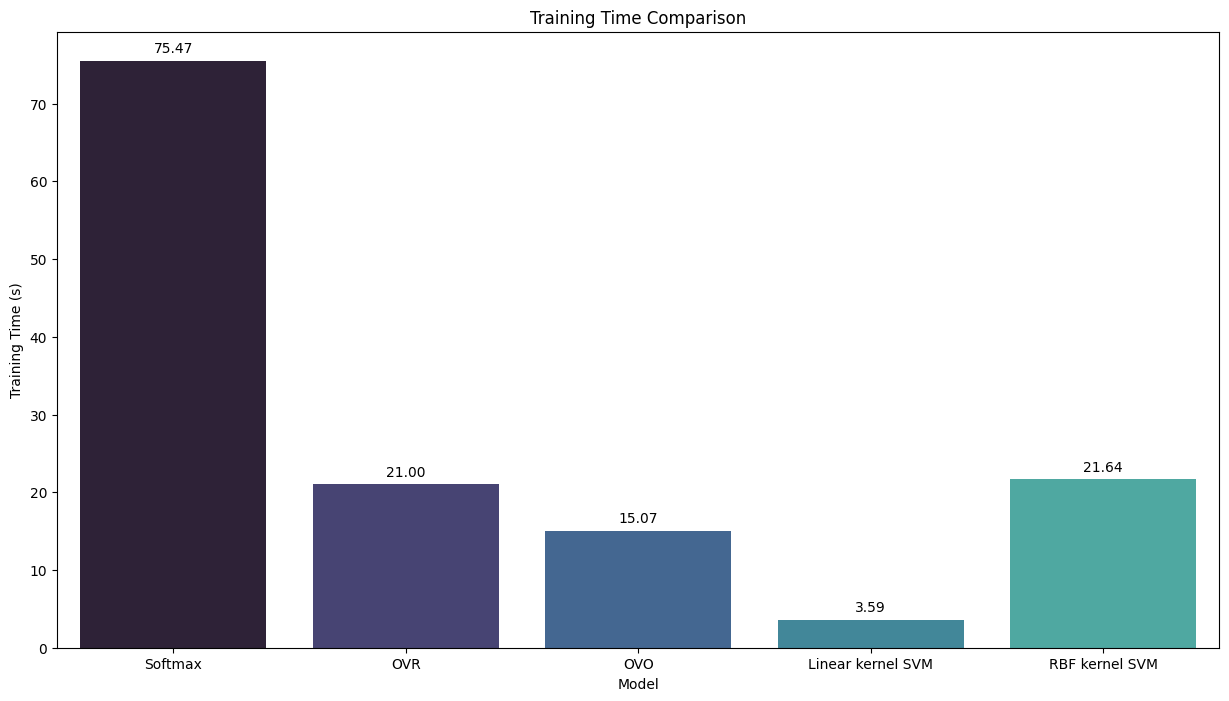

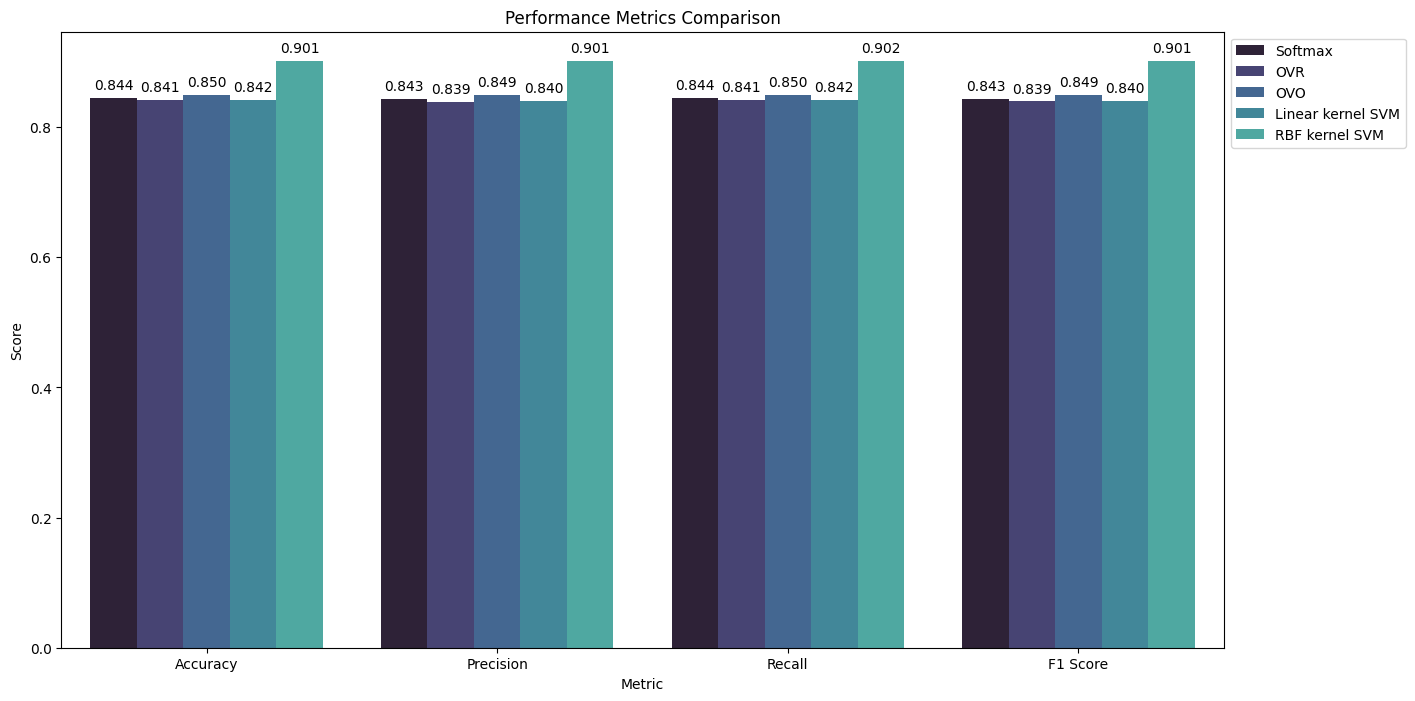

In [90]:
custom_palette = sns.color_palette("mako", as_cmap=False)  # "viridis" is a gradient palette
sns.set_palette(custom_palette)

# Plotting training time comparison
plt.figure(figsize=(15, 8))
ax = sns.barplot(x='Model', y='Training Time (s)', data=all_model_df)
plt.title('Training Time Comparison')

# Hiển thị giá trị trên cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')
plt.show()

# Plotting performance metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
df_melted = all_model_df.melt(id_vars=['Model'], value_vars=metrics, var_name='Metric', value_name='Score')

plt.figure(figsize=(15, 8))
ax = sns.barplot(x='Metric', y='Score', hue='Model', data=df_melted)
plt.title('Performance Metrics Comparison')

# Hiển thị giá trị trên cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

**Nhận xét và đánh giá**
* So về thời gian chạy thì mô hình linear kernel SVM nhanh hơn rất nhiều so với các mô hình khác (3.77s). Nhưng về độ chính xác thì gần như tương tự và không có đột phá so với các mô hình khác (ở mức khoảng 84%)
* Theo như các điểm số đánh giá thì độ chính xác của mô hình RBF có sự đột phá rất lớn so với các mô hình còn lại (ở mức 90,1%). Thời gian chạy của mô hình tuy lớn hơn rất nhiều so với linear nhưng ở mức chấp nhận được
* mô hình Logistic Regression (OvO) và (OvR) cho ra kết quả khá tốt (85%) và (84%). ở mô hình OvO thời gian chạy khá ngắn do tối ưu được việc chạy song song trên GPU
* Softmax cho ra kết quả gần tương tự với các mô hình OvO, OVR, linear kernel SVM. nhưng thời gian chạy quá lâu so với mặt bằng chung của các mô hình (67.12s) làm tiêu tốn khá nhiều tài nguyên dù được chạy trên GPU

### Trực quan những hình ảnh trong những cặp lớp dễ nhầm lẫn

In [91]:
data = {'Softmax': pred_softmax.get(), 'OVR': pred_ovr.get(), 'OVO': pred_ovo.get(), 'Linear kernel': pred_svc_linear.get().astype('int32'), 'RBF kernel': pred_svc_rbf.get(), 'Test label': test_labels.get() }

In [92]:
df = pd.DataFrame(data)
df

,Softmax,OVR,OVO,Linear kernel,RBF kernel,Test label
0,9,9,9,9,9,9
1,2,2,2,2,2,2
2,1,1,1,1,1,1
3,1,1,1,1,1,1
4,6,6,6,6,6,6
...,...,...,...,...,...,...
9995,9,9,9,9,9,9
9996,1,1,1,1,1,1
9997,6,6,6,8,8,8
9998,1,1,1,1,1,1


Model SVC với kernel RBF có độ chính xác khá cao (lớn hơn 90%). Chỉ có một cặp lớp dễ bị nhầm lẫn trong model này là 'T-shirt/top' vs 'Shirt'. Nên ta sẽ chỉ thực hiện trên những model còn lại (vì trong những cặp lớp dễ bị nhầm lẫn trong những model còn lại cũng có 'T-shirt/top' vs 'Shirt')

In [93]:
df = df.drop('RBF kernel', axis=1)

Các cặp lớp dễ bị nhầm lẫn:
* 'Pullover' vs 'Coat' : 2 vs 4
* 'Shirt' vs 'Coat': 6 vs 4
* 'Shirt' vs 'Pullover': 6 vs 2
* 'Shirt' vs 'T-shirt/top': 6 vs 0


#### 'Pullover' vs 'Coat'

In [94]:
filtered_df1 = df[(df.iloc[:, :4].eq(2).sum(axis=1) >= 3) & (df['Test label'] == 4)]
filtered_df2 = df[(df.iloc[:, :4].eq(4).sum(axis=1) >= 3) & (df['Test label'] == 2)]

In [95]:
def showImageClass(df1, df2,  df=test_images.get(), n=5):
    plt.figure(figsize=(10, 10), dpi=150)
    # Lấy n chỉ số ngẫu nhiên từ df1
    random_indices = np.random.choice(df1.index, n, replace=False)  
    random_indices_df2 = np.random.choice(df2.index, n, replace=False)
    
    for i in range(n):
        plt.subplot(1, n, i + 1)  
        index = random_indices[i]
        image_data = df[index].reshape(28, 28)  
        plt.imshow(image_data, cmap='gray')
        plt.xticks([])
        plt.yticks([])
    plt.show()
    plt.figure(figsize=(10, 10), dpi=150)
    for i in range(n): 
        plt.subplot(2, n, i + 1 + n)  
        index2 = random_indices_df2[i]
        image_data2 = df[index2].reshape(28, 28)  
        plt.imshow(image_data2, cmap='gray')
        plt.xticks([])
        plt.yticks([])
    plt.show()

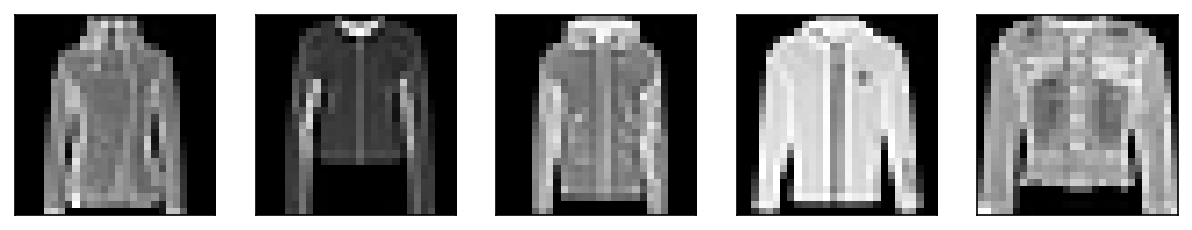

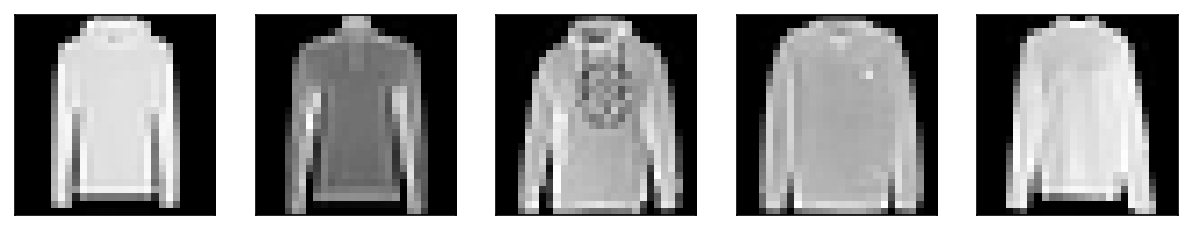

In [96]:
showImageClass(filtered_df1,filtered_df2)

#### 'Shirt' vs 'Coat'

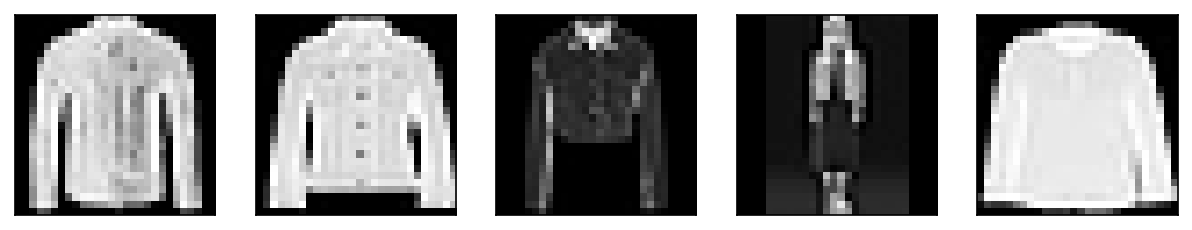

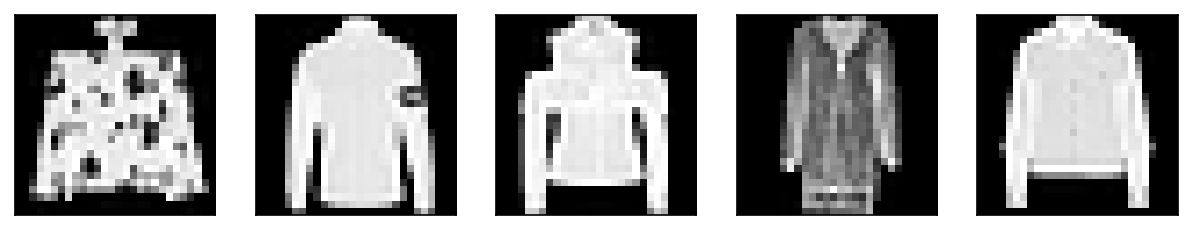

In [97]:
filtered_df1 = df[(df.iloc[:, :4].eq(6).sum(axis=1) >= 3) & (df['Test label'] == 4)]
filtered_df2 = df[(df.iloc[:, :4].eq(4).sum(axis=1) >= 3) & (df['Test label'] == 6)]
showImageClass(filtered_df1,filtered_df2)

#### 'Shirt'vs 'Pullover'

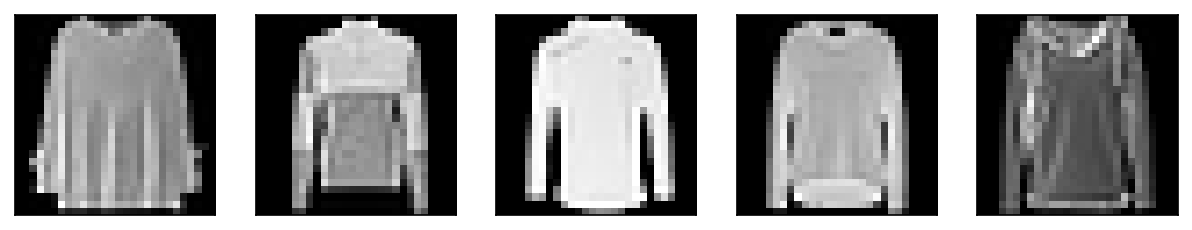

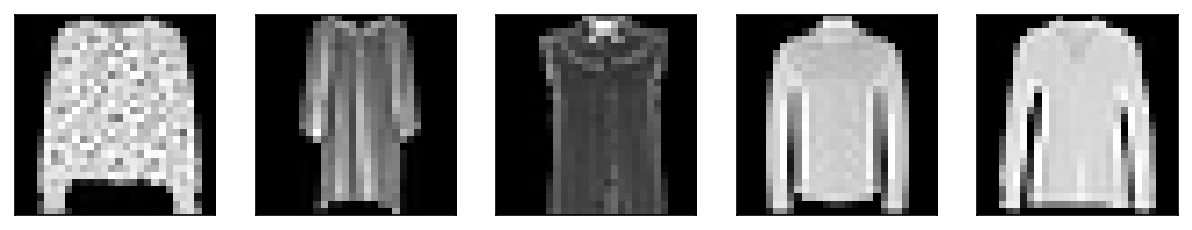

In [98]:
filtered_df1 = df[(df.iloc[:, :4].eq(6).sum(axis=1) >= 3) & (df['Test label'] == 2)]
filtered_df2 = df[(df.iloc[:, :4].eq(2).sum(axis=1) >= 3) & (df['Test label'] == 6)]
showImageClass(filtered_df1,filtered_df2)

#### 'Shirt' vs 'T-shirt/top'

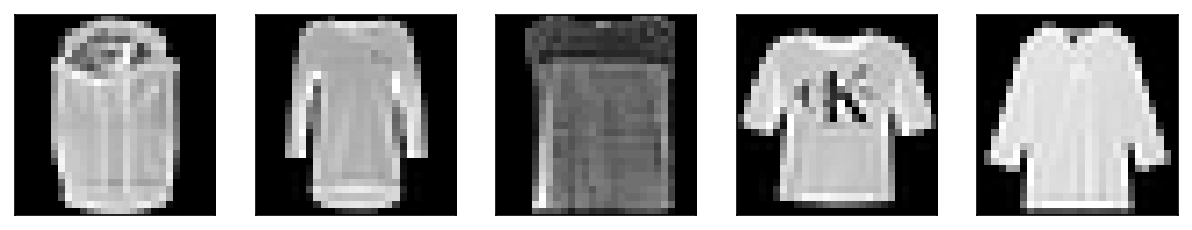

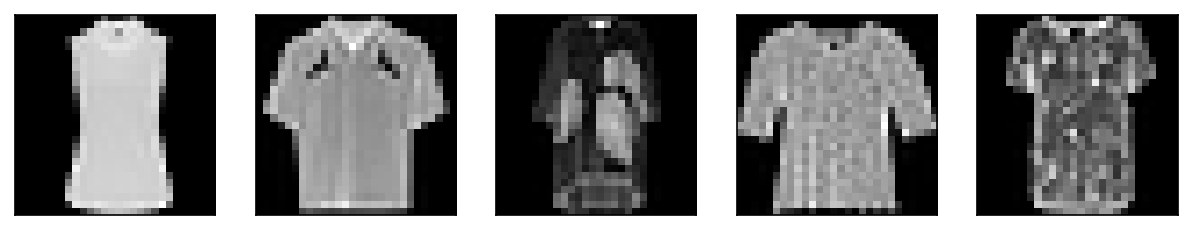

In [99]:
filtered_df1 = df[(df.iloc[:, :4].eq(6).sum(axis=1) >= 3) & (df['Test label'] == 0)]
filtered_df2 = df[(df.iloc[:, :4].eq(0).sum(axis=1) >= 3) & (df['Test label'] == 6)]
showImageClass(filtered_df1,filtered_df2)

Dựa vào những hình ảnh trực quan giữa những hình bị nhầm lần giữa các lớp. Ta thấy có sự tương đồng khá lớn về kiểu dáng, còn về màu sắc do dữ liệu là hình trắng đen nên dễ có sự tương đồng với nhau. Vì vậy nên các mô hình dễ bị nhầm lẫn giữa các lớp này (các hình được lấy random từ những dự đoán nhầm lẫn của các mô hình)

# PCA

## Experiment with 2 principal components 

In [105]:
from cuml.decomposition import PCA

In [111]:
pca_2 = PCA(n_components = 2)
X_r = pca_2.fit_transform(train_images)

In [112]:
pc2_array = np.concatenate([X_r, train_labels.reshape(-1, 1)], axis=1)

In [113]:
pc2_df = pd.DataFrame(pc2_array.get(), columns=['PC1', 'PC2', 'Label'])
pc2_df['Label'] = pc2_df['Label'].astype(int)

<Axes: xlabel='PC1', ylabel='PC2'>

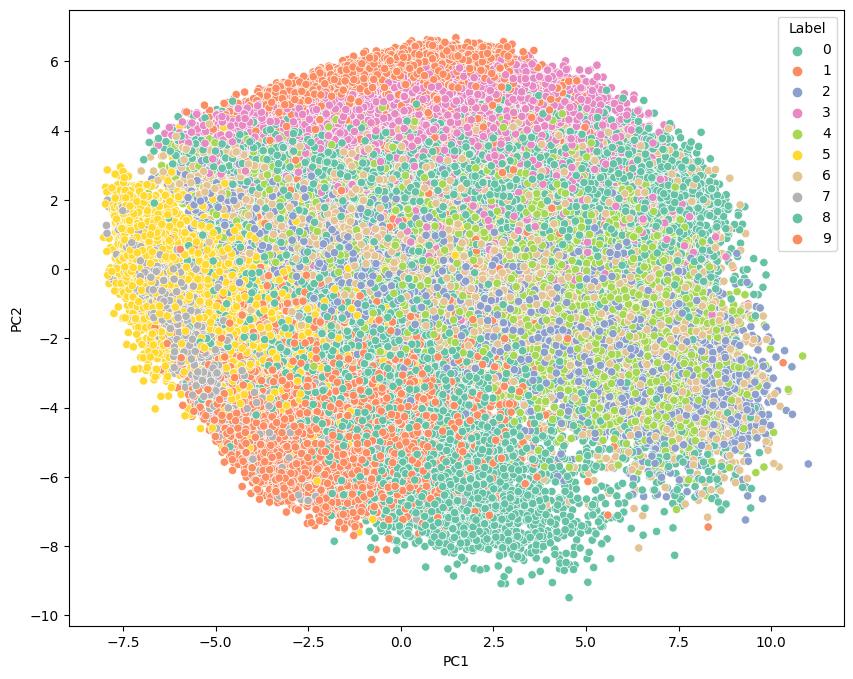

In [114]:
#plotting dataset into 2d graph
plt.figure(figsize = (10,8))
sns.scatterplot(
    x = "PC1", y = "PC2",
    hue = "Label",
    palette = sns.mpl_palette("Set2", 10),
    data = pc2_df,
    legend = "full",
    alpha = 1.0,
)

### Exlanied variance

In [115]:
X_r = pca_2.fit(train_images).transform(train_images)
print(f'explained variance: {pca_2.explained_variance_ratio_}')

explained variance: [0.29031546 0.17751808]


Phương sai giải thích được: Các giá trị này cho biết lượng thông tin (hay độ biến thiên) mà mỗi thành phần giữ lại được từ dữ liệu gốc. Phương sai giải thích càng cao, thành phần đó càng quan trọng trong việc biểu diễn dữ liệu ban đầu.

Thành phần PCA đầu tiên chiếm 29.03% của tổng phương sai trong dữ liệu.

Thành phần PCA thứ hai chiếm 17.75% của tổng phương sai.


### Visualize conponents vector

Kích thước ảnh gốc: Ảnh gốc của chúng ta có kích thước 28x28 pixel, nghĩa là mỗi ảnh bao gồm 28×28=784 điểm ảnh (pixel).

Khi xử lý bằng các thuật toán học máy hoặc PCA, ảnh thường được chuyển thành vector có 784 phần tử, mỗi phần tử đại diện cho một pixel.

Trong PCA, mỗi thành phần chính (principal component) là một vector với chiều dài bằng với số đặc trưng ban đầu của dữ liệu, tức là 784 phần tử trong trường hợp này.

Text(0.5, 0.98, '2-Component PCA')

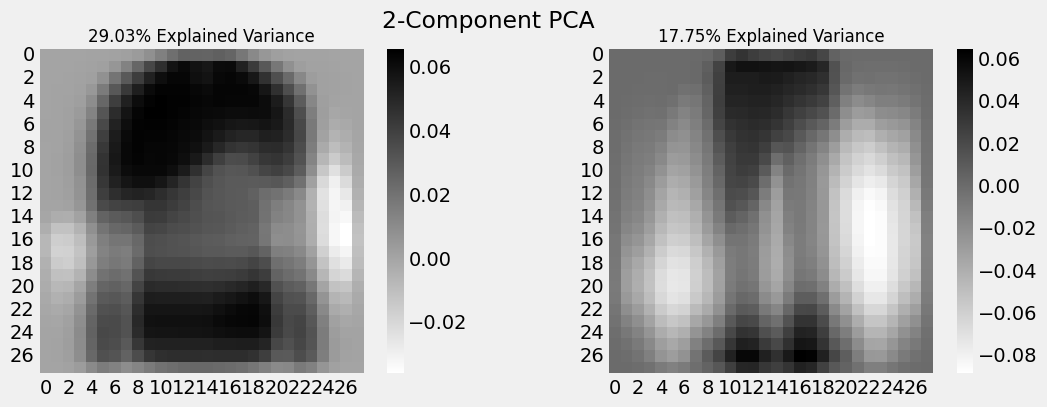

In [116]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

fig, axarr = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(pca_2.components_[0, :].get().reshape(28, 28), ax=axarr[0], cmap='gray_r')
sns.heatmap(pca_2.components_[1, :].get().reshape(28, 28), ax=axarr[1], cmap='gray_r')
axarr[0].set_title(
    "{0:.2f}% Explained Variance".format(pca_2.explained_variance_ratio_[0]*100),
    fontsize=12
)
axarr[1].set_title(
    "{0:.2f}% Explained Variance".format(pca_2.explained_variance_ratio_[1]*100),
    fontsize=12
)
axarr[0].set_aspect('equal')
axarr[1].set_aspect('equal')

plt.suptitle('2-Component PCA')

Heatmap này cho ta thấy các đặc trưng chính của ảnh mà PCA phát hiện được. Là hướng mà dữ liệu thay đổi nhiều nhất trong không gian gốc (phương sai lớn nhất)

Trong tập dữ liệu MNIST fashion các components vector này cho thấy các điểm ảnh nào có sự biến đổi mạnh nhất trong tập dữ liệu. Giá trị của mỗi pixel trong components (heat map sau khi reshape thành 28x28 bằng với kịch thước của ảnh) phản ánh mức độ đóng góp của pixel đó vào sự biến thiên của tổng thể tập dữ liệu. 

Các pixel có giá trị lớn (dương hoặc âm) tương đương với các vùng sáng và tối trong ảnh nghĩa là nó đóng vai trò lớn trong sự khác biệt giữa các ảnh

**Observation:**
* Trong heatmap của Component 1 (giải thích được nhiều thông tin nhất) ta thấy được hình ảnh mờ mờ của áo và giày: điều này có nghĩa là PC1 nắm bắt được mẫu biến thiên phổ biến nhất của các sản phẩm thời trang trong tập dữ liệu MNIST Fashion ở đây và áo và giày.
> Dữ liệu có xu hướng xu hướng biến thiên liên quan nhiều đến áo và giày (nhiều lớp có áo và giày) \
> Các mô hình sẽ dễ phân biệt được các lớp thuộc loại áo và giày

* Tương tự, PC2 nắm bắt được mẫu biến thiên phổ biến của các sản phẩm quần và giày trong tập dữ liệu

In [117]:
pca = PCA(n_components=784)
# Fit PCA on train_images and transform train_images
train_images_pca = pca.fit_transform(train_images)

In [121]:
# Chuyển explained variance và cumulative explained variance từ GPU sang CPU để vẽ
explained_variance_ratio = cp.asnumpy(pca.explained_variance_ratio_)
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)
step = 50
points = np.arange(1, len(cumulative_variance_ratio) + 1, step)
cumulative_variance_at_points = cumulative_variance_ratio[points - 1]

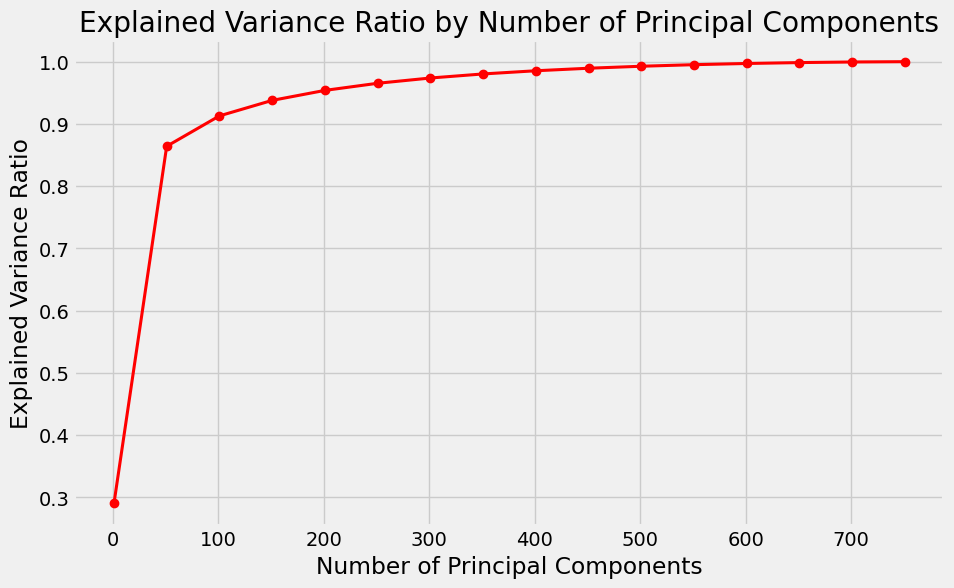

In [138]:
plt.figure(figsize=(10, 6))
plt.plot(points, cumulative_variance_at_points, marker='o', linestyle='-', linewidth = 2.2, color = 'r')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio by Number of Principal Components')
plt.grid(True)
plt.show()

Từ plot ta thấy từ 300 cho đến 784 components vẫn chưa có sự thay đổi rõ về variance giải thích được nên ta sẽ vẽ lại plot chỉ lấy từ 200 components

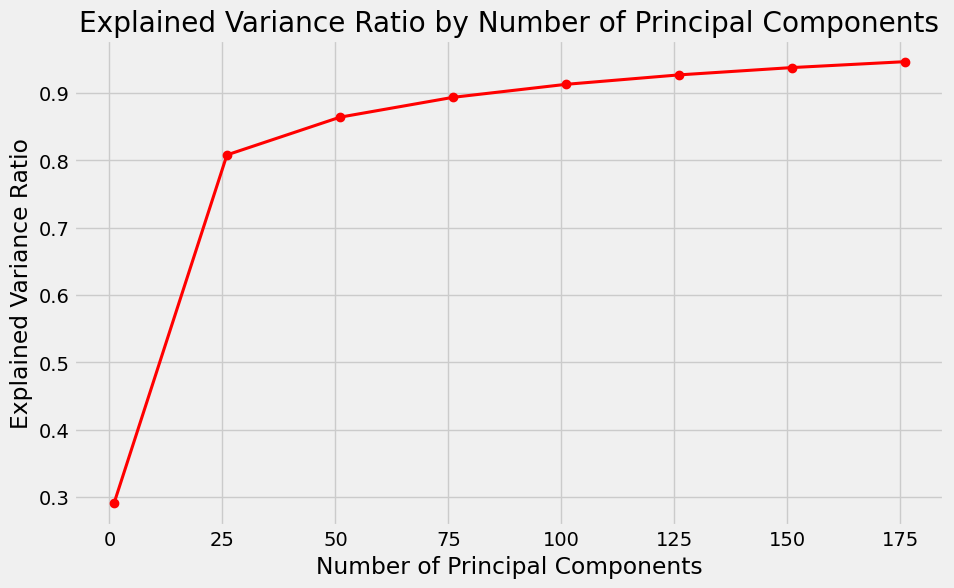

In [148]:
pca = PCA(n_components=200)
# Fit PCA on train_images and transform train_images
train_images_pca = pca.fit_transform(train_images)

# Chuyển explained variance và cumulative explained variance từ GPU sang CPU để vẽ
explained_variance_ratio = cp.asnumpy(pca.explained_variance_ratio_)
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

step = 25
points = np.arange(1, len(cumulative_variance_ratio) + 1, step)
cumulative_variance_at_points = cumulative_variance_ratio[points - 1]

plt.figure(figsize=(10, 6))
plt.plot(points, cumulative_variance_at_points, marker='o', linestyle='-', linewidth = 2.2, color = 'r')
plt.xlabel('Number of Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio by Number of Principal Components')
plt.grid(True)
plt.show()

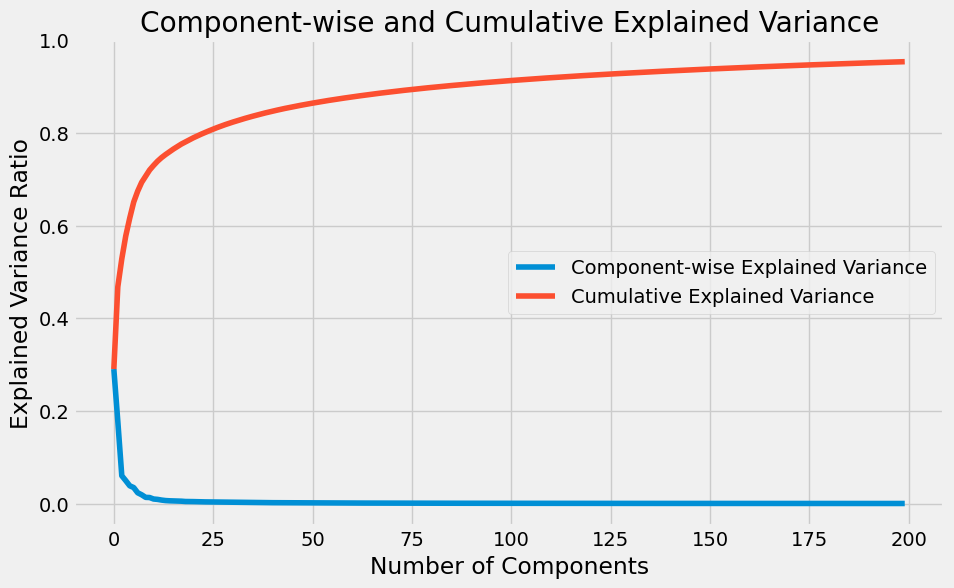

In [149]:
# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.plot(range(200), explained_variance_ratio, label="Component-wise Explained Variance")
plt.plot(range(200), cumulative_variance_ratio, label="Cumulative Explained Variance")
plt.title("Component-wise and Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Explained Variance Ratio")
plt.grid(True)
plt.legend()
plt.show()

Từ hai plot trên ta sẽ chọn số thành phần chính để giữ lại: 100 components (thực hiện PCA), song song với đó ta sẽ thực hiện thêm 25 components để có thể thấy sự khác biệt rõ rệt.

## Apply PCA

### n_components = 100

In [159]:
# Initialize PCA object
pca_100 = PCA(n_components = 100)

# Fit PCA on train_images and transform train_images
train_images_pca_100 = pca_100.fit_transform(train_images)

# Transform test_images using the same PCA model
test_images_pca_100 = pca_100.transform(test_images)

In [160]:
# Training SVM witth linear kernel model
svc_linear_model_pca_100 = LinearSVC(C=0.1) # with C = 0.1, model has the best performance

start_time = time.time()
svc_linear_model_pca_100.fit(train_images_pca_100, train_labels)
end_time = time.time()

# Calculate training time
svc_linear_pca_100_training_time = end_time - start_time

In [161]:
# Make predictions
test_predictions = svc_linear_model_pca_100.predict(test_images_pca_100)
pred_svc_linear_pca_100 = test_predictions

# Evaluate Support Vector Machine model with linear kernel
svc_linear_pca_100_accuracy = accuracy_score(test_labels, test_predictions)
svc_linear_pca_100_precision = precision_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
svc_linear_pca_100_recall = recall_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
svc_linear_pca_100_f1 = f1_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')

print(f"Training time: {svc_linear_pca_100_training_time:.2f}s")
print(f"Accuracy: {svc_linear_pca_100_accuracy:.4f}")
print(f"Precision: {svc_linear_pca_100_precision:.4f}")
print(f"Recall: {svc_linear_pca_100_recall:.4f}")
print(f"F1 Score: {svc_linear_pca_100_f1:.4f}")

Training time: 0.35s
Accuracy: 0.8340
Precision: 0.8310
Recall: 0.8340
F1 Score: 0.8314


In [162]:
# Training SVM with RBF model
svc_RBF_pca_100_model = SVC(kernel='rbf', gamma='scale', C=10) # with gamma = 'scale', C = 10, model has the best performance

start_time = time.time()
svc_RBF_pca_100_model.fit(train_images_pca_100, train_labels)
end_time = time.time()

# Time for training model
svc_RBF_pca_100_training_time = end_time - start_time

In [163]:
# Make predictions on test set
test_predictions = svc_RBF_pca_100_model.predict(test_images_pca_100)
pred_svc_rbf_pca_100 = test_predictions

# Evaluate Support Vector Machine model with rbf kernel
svc_RBF_pca_100_accuracy = accuracy_score(test_labels, test_predictions)
svc_RBF_pca_100_precision = precision_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
svc_RBF_pca_100_recall = recall_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
svc_RBF_pca_100_f1 = f1_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')

print(f"Training time: {svc_RBF_pca_100_training_time:.2f}s")
print(f"Accuracy: {svc_RBF_pca_100_accuracy:.4f}")
print(f"Precision: {svc_RBF_pca_100_precision:.4f}")
print(f"Recall: {svc_RBF_pca_100_recall:.4f}")
print(f"F1 Score: {svc_RBF_pca_100_f1:.4f}")


Training time: 9.38s
Accuracy: 0.8998
Precision: 0.8999
Recall: 0.8998
F1 Score: 0.8998


In [164]:
ovo_pca_100_model=OneVsOneClassifier(cuMLLogisticRegression(max_iter=3000))

start=time.time()
ovo_pca_100_model.fit(train_images_pca_100, train_labels)
ovo_pca_100_training_time =time.time()-start

preds =ovo_pca_100_model.predict(test_images_pca_100)
pred_ovo_pca_100 = preds

ovo_pca_100_accuracy = accuracy_score(test_labels,preds)
ovo_pca_100_precision = precision_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')
ovo_pca_100_recall = recall_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')
ovo_pca_100_f1_score = f1_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')


print(f"Training time : {ovo_pca_100_training_time : .3f}")
print(f"Accuracy : {ovo_pca_100_accuracy}")
print(f"Precision score : {ovo_pca_100_precision:} " )
print(f"Recall score: {ovo_pca_100_recall}")
print(f"F1 score : {ovo_pca_100_f1_score} ")

Training time :  3.672
Accuracy : 0.8468999862670898
Precision score : 0.8455710229343945 
Recall score: 0.8469000000000001
F1 score : 0.8460542207433168 


In [165]:
ovr_pca_100_model=OneVsRestClassifier(cuMLLogisticRegression(max_iter=3000))


start=time.time()
ovr_pca_100_model.fit(train_images_pca_100, train_labels)
ovr_pca_100_training_time =time.time()-start

preds = ovr_pca_100_model.predict(test_images_pca_100)
pred_ovr = preds

ovr_pca_100_accuracy = accuracy_score(test_labels,preds)
ovr_pca_100_precision = precision_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')
ovr_pca_100_recall = recall_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')
ovr_pca_100_f1_score = f1_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')


print(f"Training time : {ovr_pca_100_training_time : .3f}")
print(f"Accuracy : {ovr_pca_100_accuracy}")
print(f"Precision score : {ovr_pca_100_precision:} " )
print(f"Recall score: {ovr_pca_100_recall}")
print(f"F1 score : {ovr_pca_100_f1_score} ")

Training time :  2.122
Accuracy : 0.8377000093460083
Precision score : 0.8351987218772265 
Recall score: 0.8376999999999999
F1 score : 0.8357949807955004 


In [166]:
# Train Logistic Regression with multiple-class after PCA (Softmax Regression)
softmax_pca_100_model = cuMLLogisticRegression(max_iter=3000, solver='qn', fit_intercept=True) # multiple-class (using softmax loss) variants, depending on the input variables

start_time = time.time()
softmax_pca_100_model.fit(train_images_pca_100, train_labels)
end_time = time.time()

# calculate training time
softmax_pca_100_training_time = end_time - start_time

# Make predict on test-set
test_predictions = softmax_pca_100_model.predict(test_images_pca_100)
pred_softmax = test_predictions

# Evaluate softmax Regression model
softmax_pca_100_accuracy = accuracy_score(test_labels, test_predictions)
softmax_pca_100_precision = precision_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
softmax_pca_100_recall = recall_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
softmax_pca_100_f1 = f1_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')

print(f"Training time: {softmax_pca_100_training_time:.2f}s")
print(f"Accuracy: {softmax_pca_100_accuracy:.4f}")
print(f"Precision: {softmax_pca_100_precision:.4f}")
print(f"Recall: {softmax_pca_100_recall:.4f}")
print(f"F1 Score: {softmax_pca_100_f1:.4f}")

Training time: 7.35s
Accuracy: 0.8405
Precision: 0.8388
Recall: 0.8405
F1 Score: 0.8394


### Model compare & evaluation

In [167]:
data = {
    'Model': ['Softmax', 'OVR', 'OVO','SVM Linear', 'SVM RBF'],
    'Training Time (s)': [softmax_pca_100_training_time, ovr_pca_100_training_time, ovo_pca_100_training_time,svc_linear_pca_100_training_time,svc_RBF_pca_100_training_time],
    'Accuracy': [softmax_pca_100_accuracy, ovr_pca_100_accuracy, ovo_pca_100_accuracy,svc_linear_pca_100_accuracy,svc_RBF_pca_100_accuracy],
    'Precision': [softmax_pca_100_precision, ovr_pca_100_precision, ovo_pca_100_precision,svc_linear_pca_100_precision,svc_RBF_pca_100_precision],
    'Recall': [softmax_pca_100_recall, ovr_pca_100_recall, ovo_pca_100_recall, svc_linear_pca_100_recall, svc_RBF_pca_100_recall],
    'F1 Score': [softmax_pca_100_f1, ovr_pca_100_f1_score, ovo_pca_100_f1_score, svc_linear_pca_100_f1, svc_RBF_pca_100_f1]
}
model_df = pd.DataFrame(data)


In [168]:
model_df

,Model,Training Time (s),Accuracy,Precision,Recall,F1 Score
0,Softmax,7.348767,0.8405,0.838781,0.8405,0.839360
1,OVR,2.122369,0.8377,0.835199,0.8377,0.835795
2,OVO,3.672478,0.8469,0.845571,0.8469,0.846054
3,SVM Linear,0.345026,0.8340,0.830960,0.8340,0.831414
4,SVM RBF,9.378572,0.8998,0.899943,0.8998,0.899770


## 

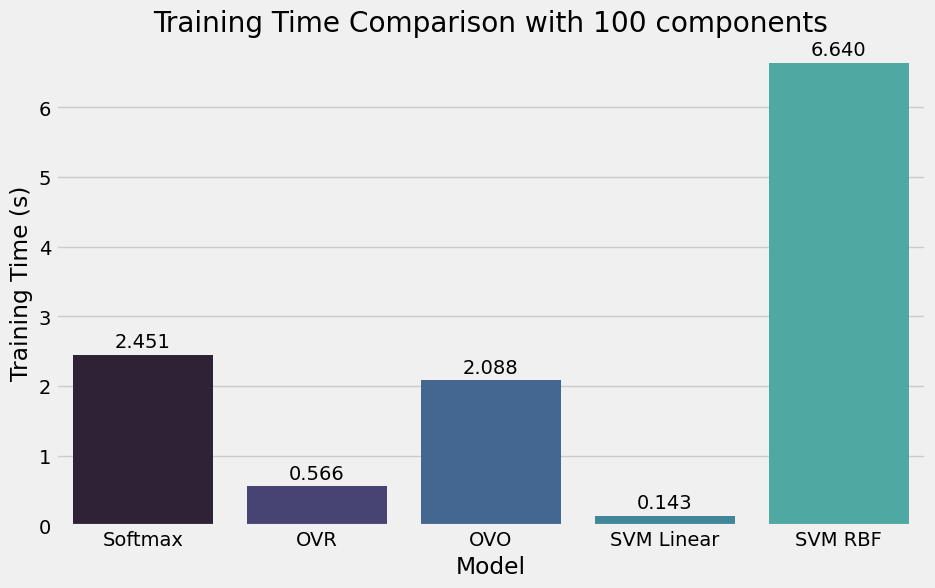

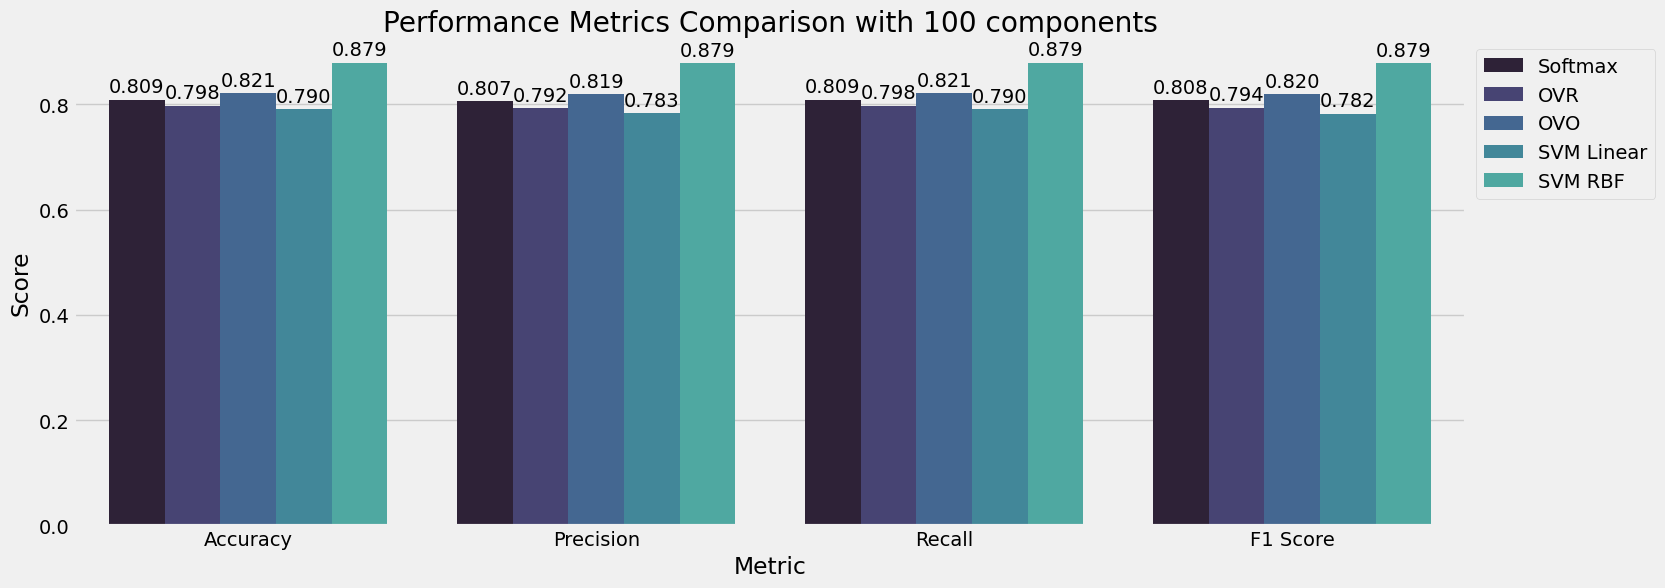

In [213]:
custom_palette = sns.color_palette("mako", as_cmap=False)  # "viridis" is a gradient palette
sns.set_palette(custom_palette)

# Plotting training time comparison
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='Training Time (s)', data=model_df)
plt.title('Training Time Comparison with 100 components')

# Hiển thị giá trị trên cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')
plt.show()

# Plotting performance metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
df_melted = model_df.melt(id_vars=['Model'], value_vars=metrics, var_name='Metric', value_name='Score')

plt.figure(figsize=(16, 6))
ax = sns.barplot(x='Metric', y='Score', hue='Model', data=df_melted)
plt.title('Performance Metrics Comparison with 100 components')

# Hiển thị giá trị trên cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

* Training time: có sự thay đổi đáng kể ở thời gian huấn luyện các mô hình khi chỉ sử dụng 100 components
> SVM với linear kernel vẫn là mô hình có thời gian huấn luyện nhanh nhất (0.345s), tiếp theo là OvR (2.122s), OvO (3.672s)\
> Sofmax không còn là mô hình chạy chậm nhất nữa (7.349s). Mô hình chạy chậm nhất là SVM với RBF kernel (9.379s)
* Các điểm số đánh giá gần như không có gì thay đổi so với trước khi PCA

In [189]:
TrainingTimes = {
    'Model': ['Softmax', 'OVR', 'OVO','SVM Linear', 'SVM RBF'],
    'Training Time before PCA (s)': [softmax_training_time, ovr_training_time, ovo_training_time,svc_linear_training_time,svc_RBF_training_time],
    'Training Time after PCA (s)': [softmax_pca_100_training_time, ovr_pca_100_training_time, ovo_pca_100_training_time,svc_linear_pca_100_training_time,svc_RBF_pca_100_training_time]
}
df_training_times_100 = pd.DataFrame(TrainingTimes)

Accuracy = {
    'Model': ['Softmax', 'OVR', 'OVO','SVM Linear', 'SVM RBF'],
    'Accuracy before PCA': [softmax_accuracy, ovr_accuracy, ovo_accuracy,svc_linear_accuracy,svc_RBF_accuracy],
    'Accuracy after PCA': [softmax_pca_100_accuracy, ovr_pca_100_accuracy, ovo_pca_100_accuracy,svc_linear_pca_100_accuracy,svc_RBF_pca_100_accuracy],
}
df_accuracy_100 = pd.DataFrame(Accuracy)

Precision = {
    'Model': ['Softmax', 'OVR', 'OVO','SVM Linear', 'SVM RBF'],
    'Precision before PCA': [softmax_precision, ovr_precision, ovo_precision,svc_linear_precision,svc_RBF_precision],
    'Precision after PCA': [softmax_pca_100_precision, ovr_pca_100_precision, ovo_pca_100_precision,svc_linear_pca_100_precision,svc_RBF_pca_100_precision],
}
df_precision_100 = pd.DataFrame(Precision)

Recall = {
    'Model': ['Softmax', 'OVR', 'OVO','SVM Linear', 'SVM RBF'],
    'Recall before PCA': [softmax_recall, ovr_recall, ovo_recall, svc_linear_recall, svc_RBF_recall],
    'Recall after PCA': [softmax_pca_100_recall, ovr_pca_100_recall, ovo_pca_100_recall, svc_linear_pca_100_recall, svc_RBF_pca_100_recall],
}
df_recall_100 = pd.DataFrame(Recall)

F1_Score = {
    'Model': ['Softmax', 'OVR', 'OVO','SVM Linear', 'SVM RBF'],
    'F1 Score before PCA': [softmax_f1, ovr_f1_score, ovo_f1_score, svc_linear_f1, svc_RBF_f1],
    'F1 Score after PCA': [softmax_pca_100_f1, ovr_pca_100_f1_score, ovo_pca_100_f1_score, svc_linear_pca_100_f1, svc_RBF_pca_100_f1]
}
df_f1_score_100 = pd.DataFrame(F1_Score)

In [190]:
df_training_times_100

,Model,Training Time before PCA (s),Training Time after PCA (s)
0,Softmax,75.470860,7.348767
1,OVR,21.004601,2.122369
2,OVO,15.065382,3.672478
3,SVM Linear,3.593835,0.345026
4,SVM RBF,21.642895,9.378572


Thời gian huấn luyện của các mô hình đều giảm rõ rệt 
* Thời gian huấn luyện của các mô hình như Softmax, OvR, SVM Linear đều giảm khoảng 10 lần so với trước khi PCA
* OvO giảm khoảng 4 lần và SVM RBF giảm khoảng 2.5 lần

In [191]:
df_accuracy_100

,Model,Accuracy before PCA,Accuracy after PCA
0,Softmax,0.8443,0.8405
1,OVR,0.8411,0.8377
2,OVO,0.8501,0.8469
3,SVM Linear,0.8424,0.8340
4,SVM RBF,0.9015,0.8998


In [192]:
df_precision_100

,Model,Precision before PCA,Precision after PCA
0,Softmax,0.843064,0.838781
1,OVR,0.838992,0.835199
2,OVO,0.848817,0.845571
3,SVM Linear,0.839682,0.830960
4,SVM RBF,0.901396,0.899943


In [193]:
df_recall_100

,Model,Recall before PCA,Recall after PCA
0,Softmax,0.8443,0.8405
1,OVR,0.8411,0.8377
2,OVO,0.8501,0.8469
3,SVM Linear,0.8424,0.8340
4,SVM RBF,0.9015,0.8998


In [194]:
df_f1_score_100

,Model,F1 Score before PCA,F1 Score after PCA
0,Softmax,0.843444,0.839360
1,OVR,0.839416,0.835795
2,OVO,0.849350,0.846054
3,SVM Linear,0.840006,0.831414
4,SVM RBF,0.901404,0.899770


Các điểm số của các mô hình có giảm nhưng rất nhỏ. Nên ta có thể cân nhắc giảm thêm chiều của dữ liệu

### n_components = 25

In [195]:
# Initialize PCA object
pca = PCA(n_components = 25)

# Fit PCA on train_images and transform train_images
train_images_pca_25 = pca.fit_transform(train_images)

# Transform test_images using the same PCA model
test_images_pca_25 = pca.transform(test_images)

In [196]:
# Training SVM witth linear kernel model
svc_linear_model_pca_25 = LinearSVC(C=0.1) # with C = 0.1, model has the best performance

start_time = time.time()
svc_linear_model_pca_25.fit(train_images_pca_25, train_labels)
end_time = time.time()

# Calculate training time
svc_linear_pca_training_time_25 = end_time - start_time

In [197]:
# Make predictions
test_predictions = svc_linear_model_pca_25.predict(test_images_pca_25)
pred_svc_linear_pca = test_predictions

# Evaluate Support Vector Machine model with linear kernel
svc_linear_pca_accuracy_25 = accuracy_score(test_labels, test_predictions)
svc_linear_pca_precision_25 = precision_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
svc_linear_pca_recall_25 = recall_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
svc_linear_pca_f1_25 = f1_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')

print(f"Training time: {svc_linear_pca_training_time_25:.2f}s")
print(f"Accuracy: {svc_linear_pca_accuracy_25:.4f}")
print(f"Precision: {svc_linear_pca_precision_25:.4f}")
print(f"Recall: {svc_linear_pca_recall_25:.4f}")
print(f"F1 Score: {svc_linear_pca_f1_25:.4f}")

Training time: 0.14s
Accuracy: 0.7905
Precision: 0.7832
Recall: 0.7905
F1 Score: 0.7824


In [198]:
# Training SVM with RBF model
svc_RBF_pca_model_25 = SVC(kernel='rbf', gamma='scale', C=10) # with gamma = 'scale', C = 10, model has the best performance

start_time = time.time()
svc_RBF_pca_model_25.fit(train_images_pca_25, train_labels)
end_time = time.time()

# Time for training model
svc_RBF_pca_training_time_25 = end_time - start_time

In [199]:
# Make predictions on test set
test_predictions = svc_RBF_pca_model_25.predict(test_images_pca_25)
pred_svc_rbf_pca = test_predictions

# Evaluate Support Vector Machine model with rbf kernel
svc_RBF_pca_accuracy_25 = accuracy_score(test_labels, test_predictions)
svc_RBF_pca_precision_25 = precision_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
svc_RBF_pca_recall_25 = recall_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
svc_RBF_pca_f1_25 = f1_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')

print(f"Training time: {svc_RBF_pca_training_time_25:.2f}s")
print(f"Accuracy: {svc_RBF_pca_accuracy_25:.4f}")
print(f"Precision: {svc_RBF_pca_precision_25:.4f}")
print(f"Recall: {svc_RBF_pca_recall_25:.4f}")
print(f"F1 Score: {svc_RBF_pca_f1_25:.4f}")


Training time: 6.64s
Accuracy: 0.8790
Precision: 0.8785
Recall: 0.8790
F1 Score: 0.8786


In [200]:
ovo_pca_model_25=OneVsOneClassifier(cuMLLogisticRegression(max_iter=3000))

start=time.time()
ovo_pca_model_25.fit(train_images_pca_25, train_labels)
ovo_pca_training_time_25 =time.time()-start

preds =ovo_pca_model_25.predict(test_images_pca_25)
pred_ovo_pca = preds

ovo_pca_accuracy_25 = accuracy_score(test_labels,preds)
ovo_pca_precision_25 = precision_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')
ovo_pca_recall_25 = recall_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')
ovo_pca_f1_score_25 = f1_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')


print(f"Training time : {ovo_pca_training_time_25 : .3f}")
print(f"Accuracy : {ovo_pca_accuracy_25}")
print(f"Precision score : {ovo_pca_precision_25:} " )
print(f"Recall score: {ovo_pca_recall_25}")
print(f"F1 score : {ovo_pca_f1_score_25} ")

Training time :  2.088
Accuracy : 0.8209999799728394
Precision score : 0.8190422009710282 
Recall score: 0.8210000000000001
F1 score : 0.8196967317947104 


In [201]:
ovr_pca_model_25=OneVsRestClassifier(cuMLLogisticRegression(max_iter=3000))


start=time.time()
ovr_pca_model_25.fit(train_images_pca_25, train_labels)
ovr_pca_training_time =time.time()-start

preds = ovr_pca_model_25.predict(test_images_pca_25)
pred_ovr = preds

ovr_pca_accuracy_25 = accuracy_score(test_labels,preds)
ovr_pca_precision_25 = precision_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')
ovr_pca_recall_25 = recall_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')
ovr_pca_f1_score_25 = f1_score(cp.asnumpy(test_labels), cp.asnumpy(preds), average='macro')


print(f"Training time : {ovr_pca_training_time : .3f}")
print(f"Accuracy : {ovr_pca_accuracy_25}")
print(f"Precision score : {ovr_pca_precision_25:} " )
print(f"Recall score: {ovr_pca_recall_25}")
print(f"F1 score : {ovr_pca_f1_score_25} ")

Training time :  0.566
Accuracy : 0.7976999878883362
Precision score : 0.7922309167177752 
Recall score: 0.7977000000000001
F1 score : 0.7935335104282663 


In [202]:
# Train Logistic Regression with multiple-class after PCA (Softmax Regression) 
softmax_pca_model_25 = cuMLLogisticRegression(max_iter=3000, solver='qn', fit_intercept=True) # multiple-class (using softmax loss) variants, depending on the input variables

start_time = time.time()
softmax_pca_model_25.fit(train_images_pca_25, train_labels)
end_time = time.time()

# calculate training time
softmax_pca_training_time_25 = end_time - start_time

# Make predict on test-set
test_predictions = softmax_pca_model_25.predict(test_images_pca_25)
pred_softmax = test_predictions

# Evaluate softmax Regression model
softmax_pca_accuracy_25 = accuracy_score(test_labels, test_predictions)
softmax_pca_precision_25 = precision_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
softmax_pca_recall_25 = recall_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')
softmax_pca_f1_25 = f1_score(cp.asnumpy(test_labels), cp.asnumpy(test_predictions), average='macro')

print(f"Training time: {softmax_pca_training_time_25:.2f}s")
print(f"Accuracy: {softmax_pca_accuracy_25:.4f}")
print(f"Precision: {softmax_pca_precision_25:.4f}")
print(f"Recall: {softmax_pca_recall_25:.4f}")
print(f"F1 Score: {softmax_pca_f1_25:.4f}")

Training time: 2.45s
Accuracy: 0.8089
Precision: 0.8067
Recall: 0.8089
F1 Score: 0.8075


### Model compare & evaluation

In [203]:
data = {
    'Model': ['Softmax', 'OVR', 'OVO','SVM Linear', 'SVM RBF'],
    'Training Time (s)': [softmax_pca_training_time_25, ovr_pca_training_time, ovo_pca_training_time_25,svc_linear_pca_training_time_25,svc_RBF_pca_training_time_25],
    'Accuracy': [softmax_pca_accuracy_25, ovr_pca_accuracy_25, ovo_pca_accuracy_25,svc_linear_pca_accuracy_25,svc_RBF_pca_accuracy_25],
    'Precision': [softmax_pca_precision_25, ovr_pca_precision_25, ovo_pca_precision_25,svc_linear_pca_precision_25,svc_RBF_pca_precision_25],
    'Recall': [softmax_pca_recall_25, ovr_pca_recall_25, ovo_pca_recall_25, svc_linear_pca_recall_25, svc_RBF_pca_recall_25],
    'F1 Score': [softmax_pca_f1_25, ovr_pca_f1_score_25, ovo_pca_f1_score_25, svc_linear_pca_f1_25, svc_RBF_pca_f1_25]
}
model_df = pd.DataFrame(data)
model_df

,Model,Training Time (s),Accuracy,Precision,Recall,F1 Score
0,Softmax,2.450852,0.8089,0.806749,0.8089,0.807525
1,OVR,0.566460,0.7977,0.792231,0.7977,0.793534
2,OVO,2.088218,0.8210,0.819042,0.8210,0.819697
3,SVM Linear,0.142820,0.7905,0.783171,0.7905,0.782412
4,SVM RBF,6.639863,0.8790,0.878548,0.8790,0.878560


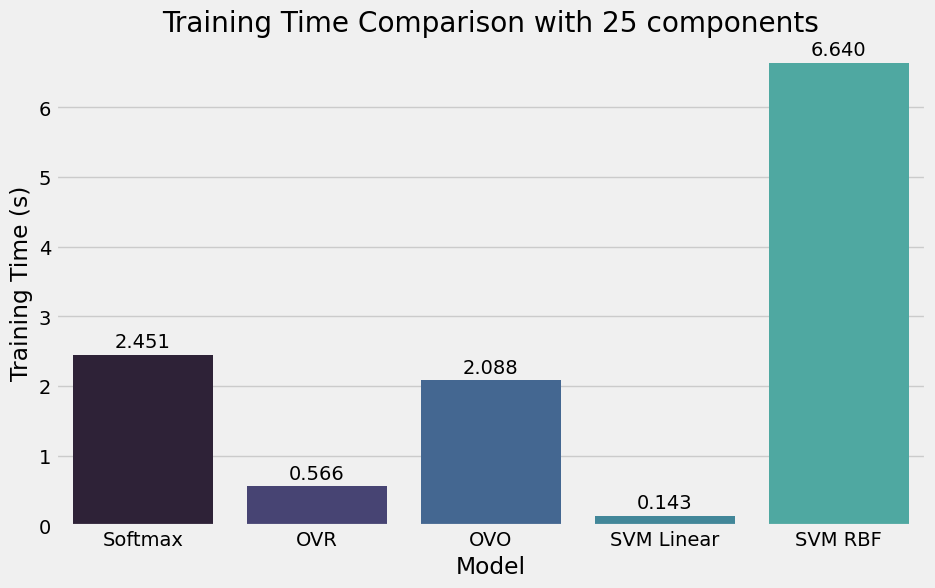

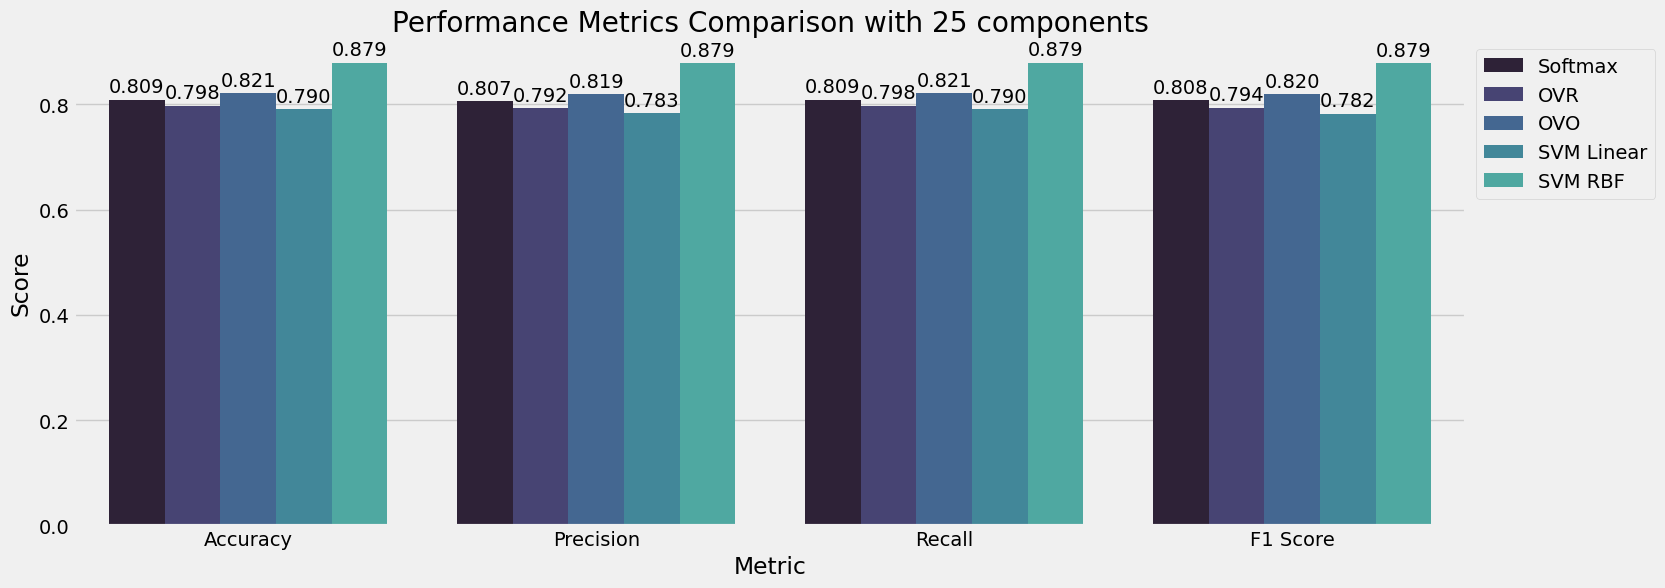

In [217]:
custom_palette = sns.color_palette("mako", as_cmap=False)  # "viridis" is a gradient palette
sns.set_palette(custom_palette)

# Plotting training time comparison
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='Training Time (s)', data=model_df)
plt.title('Training Time Comparison with 25 components')

# Hiển thị giá trị trên cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')
plt.show()

# Plotting performance metrics comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
df_melted = model_df.melt(id_vars=['Model'], value_vars=metrics, var_name='Metric', value_name='Score')

plt.figure(figsize=(16, 6))
ax = sns.barplot(x='Metric', y='Score', hue='Model', data=df_melted)
plt.title('Performance Metrics Comparison with 25 components')

# Hiển thị giá trị trên cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')
    
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

* Training time: có sự thay đổi đáng kể ở thời gian huấn luyện các mô hình khi chỉ sử dụng 25 components so với 100 components
> SVM với linear kernel vẫn là mô hình có thời gian huấn luyện nhanh nhất (0.143s), tiếp theo là OvR (0.556s), OvO (2.088s)\
> Sofmax không còn là mô hình chạy chậm nhất nữa (2.451s). Mô hình chạy chậm nhất là SVM với RBF kernel (6.640s)
* Các điểm số đánh giá của các mô hình có sự giảm nhẹ so mất đi thông tin khi giảm chiều dữ liệu

In [206]:
TrainingTimes = {
    'Model': ['Softmax', 'OVR', 'OVO','SVM Linear', 'SVM RBF'],
    'Training Time before PCA (s)': [softmax_training_time, ovr_training_time, ovo_training_time,svc_linear_training_time,svc_RBF_training_time],
     'Training Time after PCA (s)': [softmax_pca_training_time_25, ovr_pca_training_time, ovo_pca_training_time_25,svc_linear_pca_training_time_25,svc_RBF_pca_training_time_25]
}
df_training_times = pd.DataFrame(TrainingTimes)

Accuracy = {
    'Model': ['Softmax', 'OVR', 'OVO','SVM Linear', 'SVM RBF'],
    'Accuracy before PCA': [softmax_accuracy, ovr_accuracy, ovo_accuracy,svc_linear_accuracy,svc_RBF_accuracy],
    'Accuracy after PCA': [softmax_pca_accuracy_25, ovr_pca_accuracy_25, ovo_pca_accuracy_25,svc_linear_pca_accuracy_25,svc_RBF_pca_accuracy_25],
}
df_accuracy = pd.DataFrame(Accuracy)

Precision = {
    'Model': ['Softmax', 'OVR', 'OVO','SVM Linear', 'SVM RBF'],
    'Precision before PCA': [softmax_precision, ovr_precision, ovo_precision,svc_linear_precision,svc_RBF_precision],
    'Precision after PCA': [softmax_pca_precision_25, ovr_pca_precision_25, ovo_pca_precision_25,svc_linear_pca_precision_25,svc_RBF_pca_precision_25],
}
df_precision = pd.DataFrame(Precision)

Recall = {
    'Model': ['Softmax', 'OVR', 'OVO','SVM Linear', 'SVM RBF'],
    'Recall before PCA': [softmax_recall, ovr_recall, ovo_recall, svc_linear_recall, svc_RBF_recall],
    'Recall after PCA': [softmax_pca_recall_25, ovr_pca_recall_25, ovo_pca_recall_25, svc_linear_pca_recall_25, svc_RBF_pca_recall_25],
}
df_recall = pd.DataFrame(Recall)

F1_Score = {
    'Model': ['Softmax', 'OVR', 'OVO','SVM Linear', 'SVM RBF'],
    'F1 Score before PCA': [softmax_f1, ovr_f1_score, ovo_f1_score, svc_linear_f1, svc_RBF_f1],
    'F1 Score after PCA': [softmax_pca_f1_25, ovr_pca_f1_score_25, ovo_pca_f1_score_25, svc_linear_pca_f1_25, svc_RBF_pca_f1_25]
}
df_f1_score = pd.DataFrame(F1_Score)

In [207]:
df_training_times

,Model,Training Time before PCA (s),Training Time after PCA (s)
0,Softmax,75.470860,2.450852
1,OVR,21.004601,0.566460
2,OVO,15.065382,2.088218
3,SVM Linear,3.593835,0.142820
4,SVM RBF,21.642895,6.639863


In [208]:
df_accuracy

,Model,Accuracy before PCA,Accuracy after PCA
0,Softmax,0.8443,0.8089
1,OVR,0.8411,0.7977
2,OVO,0.8501,0.8210
3,SVM Linear,0.8424,0.7905
4,SVM RBF,0.9015,0.8790


In [209]:
df_precision

,Model,Precision before PCA,Precision after PCA
0,Softmax,0.843064,0.806749
1,OVR,0.838992,0.792231
2,OVO,0.848817,0.819042
3,SVM Linear,0.839682,0.783171
4,SVM RBF,0.901396,0.878548


In [210]:
df_recall

,Model,Recall before PCA,Recall after PCA
0,Softmax,0.8443,0.8089
1,OVR,0.8411,0.7977
2,OVO,0.8501,0.8210
3,SVM Linear,0.8424,0.7905
4,SVM RBF,0.9015,0.8790


In [211]:
df_f1_score

,Model,F1 Score before PCA,F1 Score after PCA
0,Softmax,0.843444,0.807525
1,OVR,0.839416,0.793534
2,OVO,0.849350,0.819697
3,SVM Linear,0.840006,0.782412
4,SVM RBF,0.901404,0.878560


### Compare running time

In [220]:
data = {
    'Model': ['Softmax', 'OVR', 'OVO','SVM Linear', 'SVM RBF'],
   'Non PCA': [softmax_training_time, ovr_training_time, ovo_training_time, svc_linear_training_time, svc_RBF_training_time, ],
   'PCA 100 components': [softmax_pca_100_training_time, ovr_pca_100_training_time, ovo_pca_100_training_time,svc_linear_pca_100_training_time,svc_RBF_pca_100_training_time],
   'PCA 25 components':  [softmax_pca_training_time_25, ovr_pca_training_time, ovo_pca_training_time_25,svc_linear_pca_training_time_25,svc_RBF_pca_training_time_25]
}
running_time_df = pd.DataFrame(data)

In [221]:
running_time_df

,Model,Non PCA,PCA 100 components,PCA 25 components
0,Softmax,75.470860,7.348767,2.450852
1,OVR,21.004601,2.122369,0.566460
2,OVO,15.065382,3.672478,2.088218
3,SVM Linear,3.593835,0.345026,0.142820
4,SVM RBF,21.642895,9.378572,6.639863


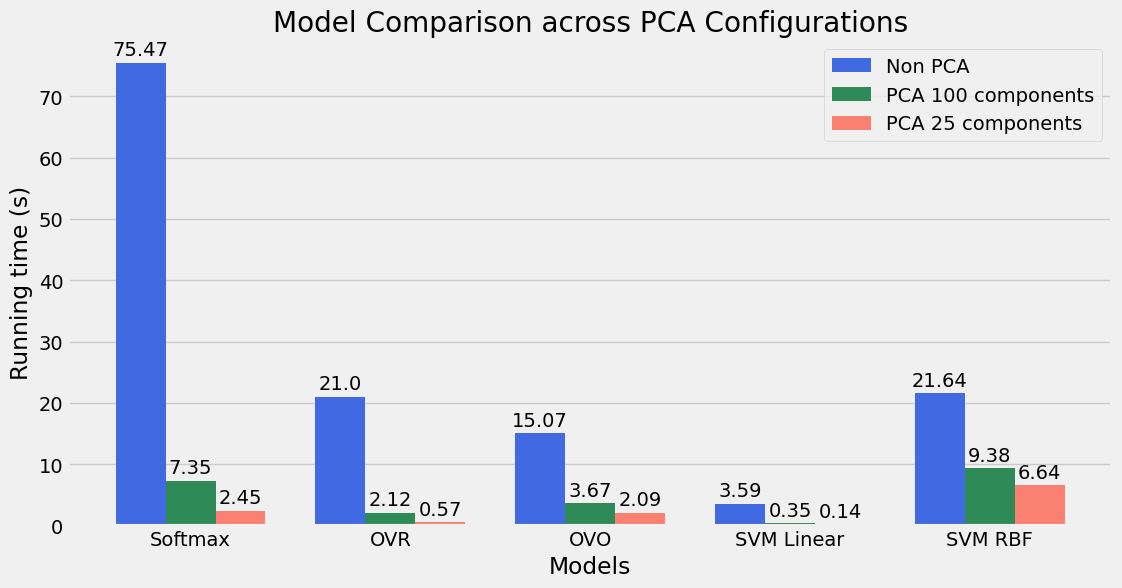

In [229]:
custom_palette = sns.color_palette("mako", as_cmap=False)  # "viridis" is a gradient palette
sns.set_palette(custom_palette)

plt.figure(figsize=(12, 6))
bar_width = 0.25
x = np.arange(len(running_time_df['Model']))

# Vẽ từng thanh bar với các cấu hình PCA khác nhau
bars1 = plt.bar(x - bar_width, running_time_df['Non PCA'], width=bar_width, label='Non PCA', color='royalblue')
bars2 = plt.bar(x, running_time_df['PCA 100 components'], width=bar_width, label='PCA 100 components', color='seagreen')
bars3 = plt.bar(x + bar_width, running_time_df['PCA 25 components'], width=bar_width, label='PCA 25 components', color='salmon')

# Thêm nhãn trục và tiêu đề
plt.xlabel('Models')
plt.ylabel('Running time (s)')
plt.title('Model Comparison across PCA Configurations')
plt.xticks(x, running_time_df['Model'])
plt.grid(axis='x')
plt.legend()

# Thêm giá trị lên đầu mỗi cột
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.5, round(yval, 2), ha='center', va='bottom')

plt.show()

## Discuss